In [1]:
# ===========================================================
# STEP 1: Install Libraries & Import Required Modules
# ===========================================================
# Purpose:
# 1. Install any missing libraries (albumentations, pydot for plotting models)
# 2. Import Python modules required for image processing, deep learning, and visualization
# 3. Set up environment for subsequent steps (dataset loading, model building, training)
# ===========================================================

# -----------------------------
# Install albumentations for image augmentation
!pip install -q albumentations

# Install pydot (needed for keras plot_model)
!pip install -q pydot

!pip install keras-tuner


# -----------------------------
# Import standard Python libraries
import os
import random
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

# -----------------------------
# Import TensorFlow and Keras modules
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import metrics

# -----------------------------
# Import sklearn modules for splitting dataset and computing metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# -----------------------------
# Import albumentations for augmentations (optional for later steps)
import albumentations as A

# -----------------------------
# Verify TensorFlow version
print("TensorFlow version:", tf.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 11.2 MB/s eta 0:00:00
TensorFlow version: 2.19.0


In [2]:
# ===========================================================
# Count total images in BUSI dataset (no masks)
# ===========================================================

from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Path to BUSI dataset
data_path = '/content/drive/MyDrive/Colab Notebooks/Dataset_BUSI_with_GT_WOD'

# Accepted image extensions
image_ext = ('.png', '.jpg', '.jpeg')

# Image counters
total_all = 0
total_normal = 0
total_benign = 0
total_malignant = 0

print("Counting images in BUSI dataset...\n")

for folder in ['normal', 'benign', 'malignant']:
    folder_path = os.path.join(data_path, folder)

    if not os.path.isdir(folder_path):
        print(f"Missing folder: {folder}")
        continue

    count = 0
    for file in os.listdir(folder_path):
        # Only count real images (exclude masks)
        if file.lower().endswith(image_ext) and "_mask" not in file.lower():
            count += 1

    # Save to class counters
    if folder == 'normal':
        total_normal = count
    elif folder == 'benign':
        total_benign = count
    elif folder == 'malignant':
        total_malignant = count

    total_all += count
    print(f"{folder.capitalize()} images: {count}")

print("\n==================================")
print(f"Total images (all classes): {total_all}")
print("==================================")


Mounted at /content/drive
Counting images in BUSI dataset...

Normal images: 133
Benign images: 437
Malignant images: 210

Total images (all classes): 780


In [3]:
# ===========================================================
# STEP 3: Inspect Dataset (Count Images and Masks per Class)
# ===========================================================
# Purpose:
# 1. Loop through each class folder: 'benign', 'malignant', 'normal'
# 2. Count number of original images and masks per class
# 3. Identify any mismatches (number of images != number of masks)
# 4. Print a clear summary for sanity check
# ===========================================================

import os

# Loop through each class folder
for folder_name in sorted(os.listdir(data_path)):
    folder_path = os.path.join(data_path, folder_name)

    # Skip if not a folder
    if not os.path.isdir(folder_path):
        continue

    # Counters
    image_counter = 0
    mask_counter = 0

    # Loop through files in the folder
    for file_name in os.listdir(folder_path):
        if "_mask" in file_name:
            mask_counter += 1
        elif file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_counter += 1

    # Display counts
    print(f"Class: {folder_name}")
    print(f"  Number of Images: {image_counter}")
    print(f"  Number of Masks : {mask_counter}")
    print("-" * 40)


Class: benign
  Number of Images: 437
  Number of Masks : 454
----------------------------------------
Class: malignant
  Number of Images: 210
  Number of Masks : 211
----------------------------------------
Class: normal
  Number of Images: 133
  Number of Masks : 133
----------------------------------------


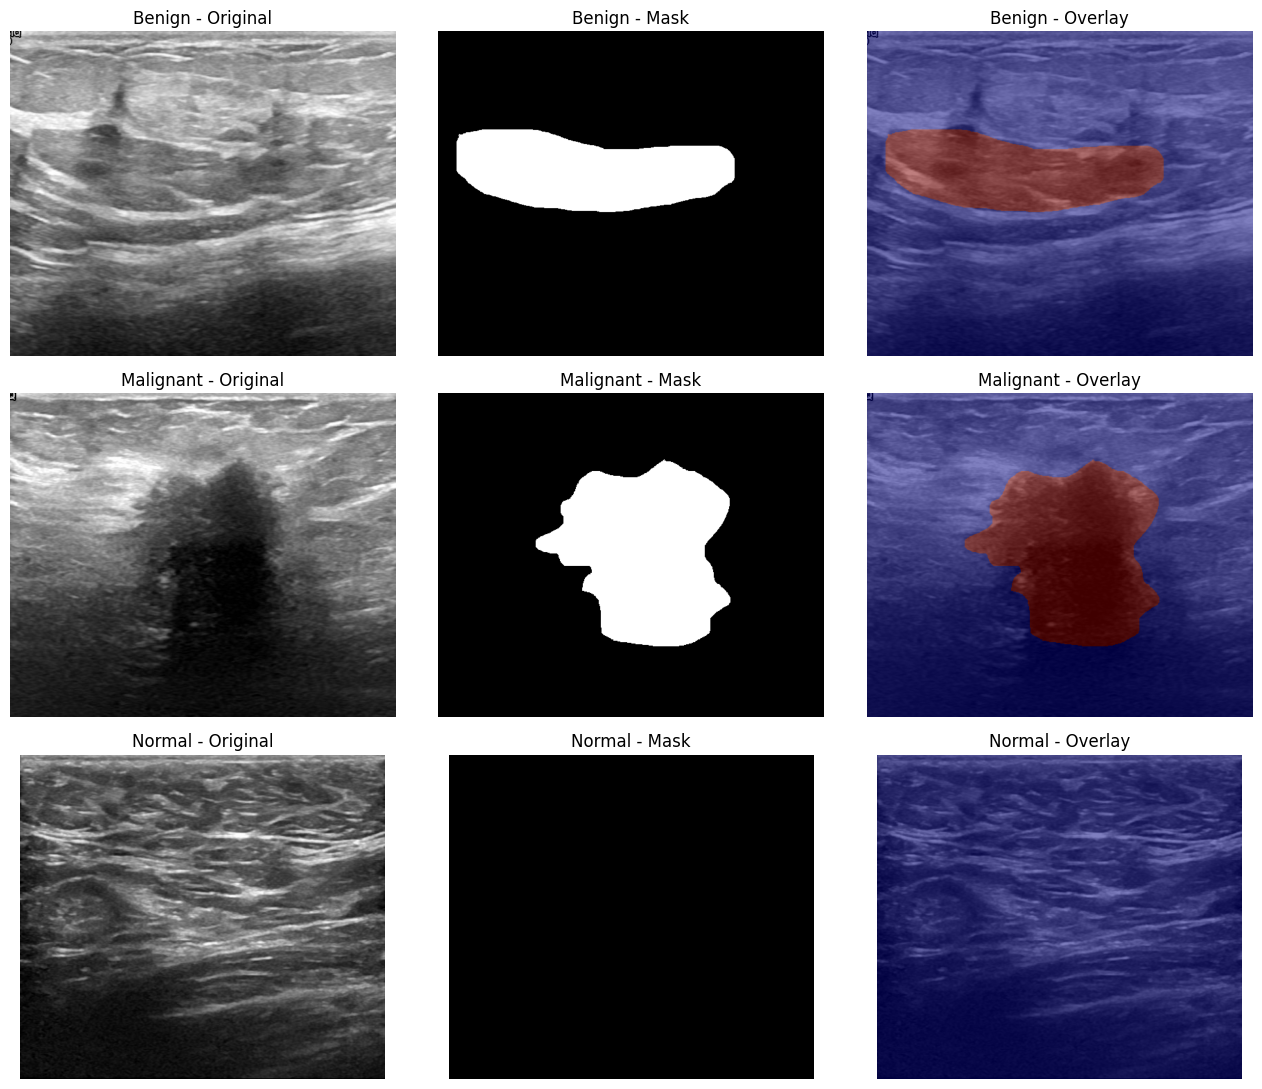

In [4]:
# ===========================================================
# STEP 4: Visualize Sample Images, Masks, and Overlays
# ===========================================================
# Purpose:
# 1. Randomly select sample images from each class: benign, malignant, normal
# 2. Display:
#    - Original grayscale image
#    - Mask (if exists)
#    - Overlay of mask on image (semi-transparent)
# 3. Verify alignment and mask correctness
# ===========================================================

import random
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image

def vis_images_all_classes(data_path, alpha=0.5):
    """
    Visualizes sample images and masks for each class.

    Args:
        data_path (str): Path to dataset folder
        alpha (float): Transparency for overlay
    """
    classes = ['benign', 'malignant', 'normal']
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(13, 11))

    for row_idx, class_name in enumerate(classes):
        class_path = os.path.join(data_path, class_name)

        # Filter original images and masks
        image_paths = sorted([
            os.path.join(class_path, f) for f in os.listdir(class_path)
            if "_mask" not in f and f.lower().endswith('.png')
        ])
        mask_paths = {
            f.replace("_mask", ""): os.path.join(class_path, f)
            for f in os.listdir(class_path) if "_mask" in f and f.lower().endswith('.png')
        }

        # Only keep images with corresponding masks (except normal)
        valid_images = [img for img in image_paths if (os.path.basename(img) in mask_paths) or class_name=='normal']

        if not valid_images:
            print(f"No valid images for class: {class_name}")
            continue

        # Randomly select one image
        img_path = random.choice(valid_images)
        mask_path = mask_paths.get(os.path.basename(img_path), None)

        # Load image
        image = np.array(Image.open(img_path).convert("RGB"))

        # Load mask if exists
        if mask_path:
            mask = np.array(Image.open(mask_path).convert("L"))
            # Convert mask to color overlay
            mask_colored = cv2.applyColorMap(mask, cv2.COLORMAP_JET)
            mask_colored = cv2.cvtColor(mask_colored, cv2.COLOR_BGR2RGB)
            overlay = cv2.addWeighted(image, 1-alpha, mask_colored, alpha, 0)
        else:
            mask = np.zeros_like(image[:,:,0])
            overlay = image.copy()

        # Plot Original
        axes[row_idx, 0].imshow(image)
        axes[row_idx, 0].set_title(f"{class_name.capitalize()} - Original")
        axes[row_idx, 0].axis("off")

        # Plot Mask
        axes[row_idx, 1].imshow(mask, cmap='gray')
        axes[row_idx, 1].set_title(f"{class_name.capitalize()} - Mask")
        axes[row_idx, 1].axis("off")

        # Plot Overlay
        axes[row_idx, 2].imshow(overlay)
        axes[row_idx, 2].set_title(f"{class_name.capitalize()} - Overlay")
        axes[row_idx, 2].axis("off")

    plt.tight_layout()
    plt.show()

# -----------------------------
# Call the visualization function
vis_images_all_classes(data_path)


Enter image code (e.g., B100, M23, N87): m13


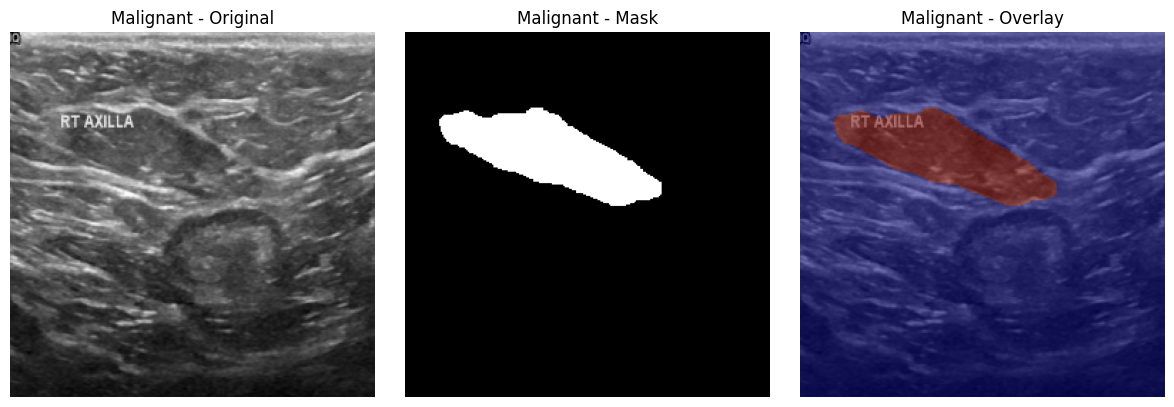

In [5]:
# ===========================================================
# STEP 5: Load Specific Image and Display Mask + Overlay
# ===========================================================
# Purpose:
# 1. Allows selection of a specific image by code (e.g., B100, M23, N87)
# 2. Loads the original image and merges all masks for that image
# 3. Displays:
#    - Original grayscale image
#    - Combined mask
#    - Overlay of mask on image
# 4. Fixes previous shape mismatch issue with overlay (grayscale -> RGB)
# ===========================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# -----------------------------
# Get user input for image code
user_input = input("Enter image code (e.g., B100, M23, N87): ").strip().upper()

# Map prefix to folder and label
prefix_map = {
    'B': ('benign', 'Benign'),
    'M': ('malignant', 'Malignant'),
    'N': ('normal', 'Normal')
}

prefix = user_input[0]
number = user_input[1:]

# Validate input
if prefix not in prefix_map or not number.isdigit():
    raise ValueError("Invalid input format. Use B/M/N followed by a number, e.g., B100.")

folder, label = prefix_map[prefix]
filename_base = f"{folder} ({number})"

image_path = os.path.join(data_path, folder, f"{filename_base}.png")
mask_dir = os.path.join(data_path, folder)

# -----------------------------
# Collect all masks corresponding to the image
mask_paths = [os.path.join(mask_dir, fname)
              for fname in os.listdir(mask_dir)
              if fname.startswith(filename_base) and "_mask" in fname]

if not os.path.exists(image_path):
    raise FileNotFoundError(f"Image not found: {image_path}")

# -----------------------------
# Load and resize image
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
image = cv2.resize(image, (256, 256))

# -----------------------------
# Merge all masks
mask_combined = np.zeros((256, 256), dtype=np.uint8)
for mask_path in mask_paths:
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
    mask_combined = np.maximum(mask_combined, mask)

# -----------------------------
# Convert grayscale image to RGB for overlay
image_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

# Convert mask to color overlay
mask_uint8 = mask_combined.astype(np.uint8)
mask_colored = cv2.applyColorMap(mask_uint8, cv2.COLORMAP_JET)
mask_colored = cv2.cvtColor(mask_colored, cv2.COLOR_BGR2RGB)

# Blend image and mask
overlay = cv2.addWeighted(image_rgb, 0.5, mask_colored, 0.5, 0)

# -----------------------------
# Display the results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title(f"{label} - Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_combined, cmap="gray")
plt.title(f"{label} - Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(f"{label} - Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()


In [6]:
# ===========================================================
# STEP 6: Load Full Dataset into Arrays (X, Y, labels)
# ===========================================================
# Purpose:
# 1. Load all images and masks for 'benign', 'malignant', and 'normal' classes
# 2. Resize images and masks to 256x256
# 3. Normalize images to [0,1]
# 4. Map masks to 3 classes (0=background, 1=benign, 2=malignant)
# 5. Prepare arrays for U-Net training: X (images), Y (masks), labels (image-level)
# ===========================================================

import os
import cv2
import numpy as np
from PIL import Image

def load_full_dataset(dataset_path, img_size=(256, 256)):
    """
    Load the full BUSI dataset into arrays for U-Net training.

    Returns:
        X: images (num_samples, H, W, 1)
        Y: masks (num_samples, H, W, 1)
        labels: image-level class labels (0=benign, 1=malignant, 2=normal)
    """
    images = []
    masks = []
    labels = []

    # Class order: benign, malignant, normal
    for label_idx, category in enumerate(['benign', 'malignant', 'normal']):
        class_path = os.path.join(dataset_path, category)
        image_files = [f for f in os.listdir(class_path) if "_mask" not in f and f.lower().endswith('.png')]

        for img_file in image_files:
            # -----------------------------
            # Load and resize image
            img_path = os.path.join(class_path, img_file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, img_size, interpolation=cv2.INTER_AREA)
            img = img / 255.0  # normalize to [0,1]
            images.append(img)
            labels.append(label_idx)

            # -----------------------------
            # Load and merge masks
            mask_paths = [os.path.join(class_path, f)
                          for f in os.listdir(class_path)
                          if f.startswith(img_file.split(".")[0]) and "_mask" in f]

            mask_combined = np.zeros(img_size, dtype=np.uint8)
            for mask_path in mask_paths:
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                mask = cv2.resize(mask, img_size, interpolation=cv2.INTER_NEAREST)
                mask_combined = np.maximum(mask_combined, mask)

            # -----------------------------
            # Map mask pixels to class indices
            if label_idx == 0:   # benign
                mask_combined = (mask_combined > 0).astype(np.uint8) * 1
            elif label_idx == 1: # malignant
                mask_combined = (mask_combined > 0).astype(np.uint8) * 2
            # normal images remain 0 (background)

            masks.append(mask_combined)

    # -----------------------------
    # Convert lists to numpy arrays
    X = np.array(images).reshape(-1, img_size[0], img_size[1], 1)
    Y = np.array(masks).reshape(-1, img_size[0], img_size[1], 1)
    labels = np.array(labels)

    return X, Y, labels

# -----------------------------
# Load the dataset
X, Y, labels = load_full_dataset(data_path)

# -----------------------------
# Verify shapes
print("Number of images:", X.shape[0])
print("Image shape:", X.shape[1:])
print("Mask shape:", Y.shape[1:])
print("Unique image-level labels:", np.unique(labels))


Number of images: 780
Image shape: (256, 256, 1)
Mask shape: (256, 256, 1)
Unique image-level labels: [0 1 2]


In [7]:
# ===========================================================
# STEP 7: Train/Validation/Test Split with Data Augmentation
# ===========================================================
# Purpose:
# 1. Split dataset into training, validation, and test sets
# 2. Ensure all classes are represented
# 3. Apply on-the-fly data augmentation for training set
# ===========================================================

import numpy as np
from sklearn.model_selection import train_test_split
import albumentations as A
import cv2

# -----------------------------
# Define classes
class_names = ['background', 'benign', 'malignant']
num_classes = len(class_names)

# -----------------------------
# Create test set ensuring each class is represented
def select_test_indices(labels, min_per_class=1):
    test_indices = []
    for cls in np.unique(labels):
        idx_list = np.where(labels == cls)[0]
        n = max(min_per_class, int(len(idx_list)*0.2))  # 20% per class
        selected = np.random.choice(idx_list, n, replace=False)
        test_indices.extend(selected)
    return test_indices

test_indices = select_test_indices(labels)
all_indices = np.arange(len(X))
train_val_indices = np.setdiff1d(all_indices, test_indices)

X_train_val = X[train_val_indices]
Y_train_val = Y[train_val_indices]
labels_train_val = labels[train_val_indices]

X_test = X[test_indices]
Y_test = Y[test_indices]

# -----------------------------
# Split train and validation sets (90% train, 10% val, stratified)
if len(np.unique(labels_train_val)) > 1:
    X_train, X_val, Y_train, Y_val = train_test_split(
        X_train_val, Y_train_val,
        test_size=0.1,
        random_state=42,
        stratify=labels_train_val
    )
else:
    X_train, X_val, Y_train, Y_val = train_test_split(
        X_train_val, Y_train_val,
        test_size=0.1,
        random_state=42
    )

# -----------------------------
# Define data augmentation for training set
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.5)
])

# Function to apply augmentation
def augment_batch(X_batch, Y_batch):
    X_aug = []
    Y_aug = []
    for img, mask in zip(X_batch, Y_batch):
        # Albumentations expects HxWxC
        augmented = train_transform(image=img.squeeze(), mask=mask.squeeze())
        X_aug.append(augmented['image'][..., np.newaxis])  # add channel dimension
        Y_aug.append(augmented['mask'][..., np.newaxis])
    return np.array(X_aug), np.array(Y_aug)

# -----------------------------
# One-hot encode masks
from tensorflow.keras.utils import to_categorical

def one_hot_encode_masks(masks, num_classes):
    masks = masks.squeeze(-1).astype(np.int32)
    return to_categorical(masks, num_classes=num_classes).astype(np.float32)

Y_train_onehot = one_hot_encode_masks(Y_train, num_classes)
Y_val_onehot   = one_hot_encode_masks(Y_val, num_classes)
Y_test_onehot  = one_hot_encode_masks(Y_test, num_classes)

# -----------------------------
# Verify shapes and pixel distribution
print("X_train shape:", X_train.shape)
print("Y_train_onehot shape:", Y_train_onehot.shape)
print("X_val shape:", X_val.shape)
print("Y_val_onehot shape:", Y_val_onehot.shape)
print("X_test shape:", X_test.shape)
print("Y_test_onehot shape:", Y_test_onehot.shape)

# Pixel distribution in training set
pixel_classes_train = np.argmax(Y_train_onehot, axis=-1).flatten()
unique, counts = np.unique(pixel_classes_train, return_counts=True)
print("Pixel distribution in training set:", dict(zip(class_names, counts)))

# -----------------------------
# ✅ Ready for Step 8: Build U-Net


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


X_train shape: (562, 256, 256, 1)
Y_train_onehot shape: (562, 256, 256, 3)
X_val shape: (63, 256, 256, 1)
Y_val_onehot shape: (63, 256, 256, 3)
X_test shape: (155, 256, 256, 1)
Y_test_onehot shape: (155, 256, 256, 3)
Pixel distribution in training set: {'background': np.int64(33871189), 'benign': np.int64(1527320), 'malignant': np.int64(1432723)}


In [8]:
# ===========================================================
# STEP 8: Build U-Net Model for Hyperparameter Search
# ===========================================================
# Purpose:
# 1. Define a HyperModel class for Keras Tuner
# 2. Search hyperparameters: filters, dropout, learning rate
# 3. Supports L2 regularization
# ===========================================================

import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers, Input
from kerastuner import HyperModel

# -----------------------------
# Convolutional Block: 3x Conv2D + BatchNorm + ReLU
def convBlock(inputs, filters, kernel_size=(3,3), l2_reg=1e-4):
    x = layers.Conv2D(filters, kernel_size, padding='same',
                      kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(l2_reg))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, kernel_size, padding='same',
                      kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, kernel_size, padding='same',
                      kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    return x

# -----------------------------
# HyperModel class for Keras Tuner
class UNetHyperModel(HyperModel):
    def __init__(self, input_shape=(256,256,1), num_classes=3):
        self.input_shape = input_shape
        self.num_classes = num_classes

    def build(self, hp):
        inputs = Input(self.input_shape)

        # -----------------------------
        # Hyperparameters
        filters = hp.Choice('filters', [16, 32, 64])
        dropoutRate = hp.Float('dropoutRate', 0.1, 0.4, step=0.1)
        l2_reg = hp.Float('l2_reg', 1e-5, 1e-3, sampling='log')

        # -----------------------------
        # Encoder
        conv1 = convBlock(inputs, filters, l2_reg=l2_reg)
        pool1 = layers.MaxPooling2D((2,2))(conv1)
        pool1 = layers.Dropout(dropoutRate)(pool1)

        conv2 = convBlock(pool1, filters*2, l2_reg=l2_reg)
        pool2 = layers.MaxPooling2D((2,2))(conv2)
        pool2 = layers.Dropout(dropoutRate)(pool2)

        conv3 = convBlock(pool2, filters*4, l2_reg=l2_reg)
        pool3 = layers.MaxPooling2D((2,2))(conv3)
        pool3 = layers.Dropout(dropoutRate)(pool3)

        conv4 = convBlock(pool3, filters*8, l2_reg=l2_reg)
        pool4 = layers.MaxPooling2D((2,2))(conv4)
        pool4 = layers.Dropout(dropoutRate)(pool4)

        conv5 = convBlock(pool4, filters*16, l2_reg=l2_reg)

        # -----------------------------
        # Decoder
        up6 = layers.Conv2DTranspose(filters*8, (3,3), strides=(2,2), padding='same')(conv5)
        up6 = layers.concatenate([up6, conv4])
        up6 = layers.Dropout(dropoutRate)(up6)
        conv6 = convBlock(up6, filters*8, l2_reg=l2_reg)

        up7 = layers.Conv2DTranspose(filters*4, (3,3), strides=(2,2), padding='same')(conv6)
        up7 = layers.concatenate([up7, conv3])
        up7 = layers.Dropout(dropoutRate)(up7)
        conv7 = convBlock(up7, filters*4, l2_reg=l2_reg)

        up8 = layers.Conv2DTranspose(filters*2, (3,3), strides=(2,2), padding='same')(conv7)
        up8 = layers.concatenate([up8, conv2])
        up8 = layers.Dropout(dropoutRate)(up8)
        conv8 = convBlock(up8, filters*2, l2_reg=l2_reg)

        up9 = layers.Conv2DTranspose(filters, (3,3), strides=(2,2), padding='same')(conv8)
        up9 = layers.concatenate([up9, conv1])
        up9 = layers.Dropout(dropoutRate)(up9)
        conv9 = convBlock(up9, filters, l2_reg=l2_reg)

        # Output layer
        outputs = layers.Conv2D(self.num_classes, (1,1), activation='softmax')(conv9)

        # -----------------------------
        # Compile model
        learning_rate = hp.Float('learning_rate', 1e-5, 5e-4, sampling='log')
        model = Model(inputs, outputs)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate),
            loss='categorical_crossentropy',
            metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
        )

        return model


/tmp/ipython-input-1589941968.py:12: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner import HyperModel


In [9]:
# ===========================================================
# STEP 9: Hyperparameter Search with Keras Tuner
# Save Best Model and Hyperparameters for Future Use
# ===========================================================

from keras_tuner import RandomSearch
from tensorflow.keras.callbacks import EarlyStopping
import json
import os

# -----------------------------
# 1️⃣ EarlyStopping for each trial (optional, speeds up search)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# -----------------------------
# 2️⃣ Define HyperModel from Step 8
unet_hypermodel = UNetHyperModel(input_shape=(256,256,1), num_classes=3)

# -----------------------------
# 3️⃣ Define tuner
tuner = RandomSearch(
    hypermodel=unet_hypermodel,
    objective='val_accuracy',      # can also use val_loss or Dice
    max_trials=10,
    executions_per_trial=1,
    directory='unet_tuner',        # saved to this folder
    project_name='BUSI_segmentation'
)

# -----------------------------
# 4️⃣ Check if best parameters already saved
hyperparam_path = '/content/drive/MyDrive/Colab Notebooks/best_unet_hyperparameters.json'
model_save_path = '/content/drive/MyDrive/Colab Notebooks/best_unet_model.keras'

if os.path.exists(hyperparam_path) and os.path.exists(model_save_path):
    print("✅ Best hyperparameters and model already saved. Loading them...")

    # Load model directly
    from tensorflow.keras.models import load_model
    best_model = load_model(model_save_path, compile=True)

    # Load hyperparameters
    with open(hyperparam_path, 'r') as f:
        best_hyperparameters = json.load(f)

    print("✅ Best hyperparameters loaded:")
    print(best_hyperparameters)

else:
    # -----------------------------
    # 5️⃣ Run tuner search (only if no saved results)
    tuner.search(
        X_train, Y_train_onehot,
        validation_data=(X_val, Y_val_onehot),
        epochs=50,
        batch_size=8,
        callbacks=[early_stop],
        verbose=1
    )

    # -----------------------------
    # 6️⃣ Get the best model
    best_model = tuner.get_best_models(num_models=1)[0]

    # -----------------------------
    # 7️⃣ Save best model
    best_model.save(model_save_path)
    print(f"✅ Best model saved at: {model_save_path}")

    # -----------------------------
    # 8️⃣ Save best hyperparameters
    best_hparams_obj = tuner.get_best_hyperparameters(num_trials=1)[0]
    with open(hyperparam_path, 'w') as f:
        json.dump(best_hparams_obj.values, f)
    print(f"✅ Best hyperparameters saved at: {hyperparam_path}")

    # -----------------------------
    # 9️⃣ Print best hyperparameters
    print("\n=== Best Hyperparameters ===")
    print(f"Filters: {best_hparams_obj.get('filters')}")
    print(f"Dropout Rate: {best_hparams_obj.get('dropoutRate')}")
    print(f"L2 Regularization: {best_hparams_obj.get('l2_reg')}")
    print(f"Learning Rate: {best_hparams_obj.get('learning_rate')}")


✅ Best hyperparameters and model already saved. Loading them...
✅ Best hyperparameters loaded:
{'filters': 32, 'dropoutRate': 0.1, 'l2_reg': 0.00040701409943592307, 'learning_rate': 5.379938672664559e-05}


In [10]:
from tensorflow.keras.models import load_model
import json

# Load saved model
best_model = load_model('/content/drive/MyDrive/Colab Notebooks/best_unet_model.keras', compile=True)

# Load hyperparameters
with open('/content/drive/MyDrive/Colab Notebooks/best_unet_hyperparameters.json', 'r') as f:
    best_hyperparameters = json.load(f)

print(best_hyperparameters)


{'filters': 32, 'dropoutRate': 0.1, 'l2_reg': 0.00040701409943592307, 'learning_rate': 5.379938672664559e-05}


In [11]:
from tensorflow.keras.models import load_model

# Path where you saved the best U-Net model
model_save_path = '/content/drive/MyDrive/Colab Notebooks/best_unet_model.keras'

# Load model



In [12]:
# ===========================================================
# STEP 10 (Fixed): Load saved U-Net model & optionally train / capture AUC
# ===========================================================

from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import json

# -----------------------------
# 1️⃣ Load the saved model (from Step 9)
model_save_path = '/content/drive/MyDrive/Colab Notebooks/best_unet_model.keras'
U_net_model = load_model(model_save_path, compile=True)
print("✅ U-Net model loaded successfully.")

# -----------------------------
# 2️⃣ Define callbacks (same as before)
checkpoint = ModelCheckpoint(
    model_save_path,  # overwrite if you want
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# -----------------------------
# 3️⃣ Optional: Fine-tune the model
# If you just want to evaluate or plot AUC, you can skip training
history = U_net_model.fit(
    X_train, Y_train_onehot,
    validation_data=(X_val, Y_val_onehot),
    epochs=50,         # shorter if just fine-tuning
    batch_size=8,
    callbacks=[checkpoint, early_stopping, reduce_lr],
    verbose=1
)

# -----------------------------
# 4️⃣ Capture overall AUC per epoch
overall_auc_train = history.history['auc']        # training set AUC per epoch
overall_auc_val   = history.history['val_auc']    # validation set AUC per epoch

# -----------------------------
# 5️⃣ Save overall AUC to JSON
auc_save_path = '/content/drive/MyDrive/Colab Notebooks/overall_auc.json'
with open(auc_save_path, 'w') as f:
    json.dump({'train': overall_auc_train, 'val': overall_auc_val}, f)
print(f"✅ Overall AUC saved to: {auc_save_path}")

# -----------------------------
# 6️⃣ Print keys and sample values
print("Training history keys:", history.history.keys())
print("First 5 epochs overall AUC (Train):", overall_auc_train[:5])
print("First 5 epochs overall AUC (Val):", overall_auc_val[:5])


✅ U-Net model loaded successfully.
Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 729ms/step - accuracy: 0.9948 - auc: 0.9999 - loss: 0.4314 - precision: 0.9948 - recall: 0.9947
Epoch 1: val_loss improved from inf to 0.43277, saving model to /content/drive/MyDrive/Colab Notebooks/best_unet_model.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 120s 967ms/step - accuracy: 0.9948 - auc: 0.9999 - loss: 0.4314 - precision: 0.9948 - recall: 0.9947 - val_accuracy: 0.9937 - val_auc: 0.9999 - val_loss: 0.4328 - val_precision: 0.9937 - val_recall: 0.9937 - learning_rate: 1.0000e-06
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.9948 - auc: 0.9999 - loss: 0.4311 - precision: 0.9948 - recall: 0.9948
Epoch 2: val_loss did not improve from 0.43277
71/71 ━━━━━━━━━━━━━━━━━━━━ 19s 263ms/step - accuracy: 0.9948 - auc: 0.9999 - loss: 0.4311 - precision: 0.9948 - recall: 0.9947 - val_accuracy: 0.9933 - val_auc: 0.9999 - val_loss: 0.4330 - val_precision: 0.9933 - val_recall: 0.9932 - learning_rate: 1.0000e-0

In [13]:
# ===========================================================
# STEP 12: Evaluate U-Net Model on Train, Validation, and Test Sets
# ===========================================================
# Purpose:
# 1. Evaluate model performance on each dataset
# 2. Capture metrics: loss, accuracy, precision, recall, AUC
# 3. Useful to identify overfitting and generalization
# ===========================================================

# Evaluate on Training set
train_metrics = U_net_model.evaluate(X_train, Y_train_onehot, verbose=1)
print("\n=== Training Set Metrics ===")
for name, value in zip(U_net_model.metrics_names, train_metrics):
    print(f"{name}: {value:.4f}")

# Evaluate on Validation set
val_metrics = U_net_model.evaluate(X_val, Y_val_onehot, verbose=1)
print("\n=== Validation Set Metrics ===")
for name, value in zip(U_net_model.metrics_names, val_metrics):
    print(f"{name}: {value:.4f}")

# Evaluate on Test set
test_metrics = U_net_model.evaluate(X_test, Y_test_onehot, verbose=1)
print("\n=== Test Set Metrics ===")
for name, value in zip(U_net_model.metrics_names, test_metrics):
    print(f"{name}: {value:.4f}")


18/18 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9952 - auc: 1.0000 - loss: 0.4299 - precision: 0.9953 - recall: 0.9952

=== Training Set Metrics ===
loss: 0.4301
compile_metrics: 0.9952
2/2 ━━━━━━━━━━━━━━━━━━━━ 23s 23s/step - accuracy: 0.9939 - auc: 0.9999 - loss: 0.4325 - precision: 0.9939 - recall: 0.9938

=== Validation Set Metrics ===
loss: 0.4328
compile_metrics: 0.9937
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 5s/step - accuracy: 0.9943 - auc: 0.9999 - loss: 0.4323 - precision: 0.9943 - recall: 0.9943

=== Test Set Metrics ===
loss: 0.4336
compile_metrics: 0.9937


In [14]:
# ===========================================================
# STEP 13: Compute Per-Class Metrics
# ===========================================================
# Purpose:
# 1. Compute pixel-wise metrics per class: precision, recall, F1-score
# 2. Compute confusion matrix per class
# 3. Compute ROC-AUC per class (one-vs-rest)
# ===========================================================

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def compute_per_class_metrics(model, X, Y_onehot, class_names):
    """
    Compute per-class metrics for multi-class segmentation.

    Args:
        model: Trained U-Net model
        X: Input images (num_samples, H, W, 1)
        Y_onehot: Ground truth masks (num_samples, H, W, num_classes)
        class_names: List of class names
    """
    # Predict probabilities
    Y_pred_prob = model.predict(X, batch_size=8)

    # Convert to class indices
    Y_pred = np.argmax(Y_pred_prob, axis=-1).flatten()
    Y_true = np.argmax(Y_onehot, axis=-1).flatten()

    # -----------------------------
    # Classification report and confusion matrix
    print("\n=== Classification Report ===")
    print(classification_report(Y_true, Y_pred, target_names=class_names, zero_division=0))

    print("\n=== Confusion Matrix ===")
    cm = confusion_matrix(Y_true, Y_pred, labels=list(range(len(class_names))))
    print(cm)

    # -----------------------------
    # ROC-AUC per class (one-vs-rest)
    print("\n=== ROC-AUC per class ===")
    for i, cls in enumerate(class_names):
        y_true_binary = (Y_true == i).astype(int)
        y_pred_prob_cls = Y_pred_prob[..., i].flatten()
        try:
            auc = roc_auc_score(y_true_binary, y_pred_prob_cls)
            print(f"{cls}: {auc:.4f}")
        except ValueError:
            print(f"{cls}: Not enough samples to compute AUC")


In [15]:
class_names = ['background', 'benign', 'malignant']

print("\n--- Train Set Metrics ---")
compute_per_class_metrics(U_net_model, X_train, Y_train_onehot, class_names)

print("\n--- Validation Set Metrics ---")
compute_per_class_metrics(U_net_model, X_val, Y_val_onehot, class_names)

print("\n--- Test Set Metrics ---")
compute_per_class_metrics(U_net_model, X_test, Y_test_onehot, class_names)



--- Train Set Metrics ---
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step

=== Classification Report ===
              precision    recall  f1-score   support

  background       1.00      1.00      1.00  33871189
      benign       0.97      0.97      0.97   1527320
   malignant       0.97      0.97      0.97   1432723

    accuracy                           1.00  36831232
   macro avg       0.98      0.98      0.98  36831232
weighted avg       1.00      1.00      1.00  36831232


=== Confusion Matrix ===
[[33785435    44759    40995]
 [   43597  1483694       29]
 [   48319      823  1383581]]

=== ROC-AUC per class ===
background: 0.9997
benign: 0.9999
malignant: 0.9998

--- Validation Set Metrics ---
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 209ms/step

=== Classification Report ===
              precision    recall  f1-score   support

  background       1.00      1.00      1.00   3846938
      benign       0.92      0.96      0.94    111858
   malignant       0.97      0.95      0.96    169972

    a

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step


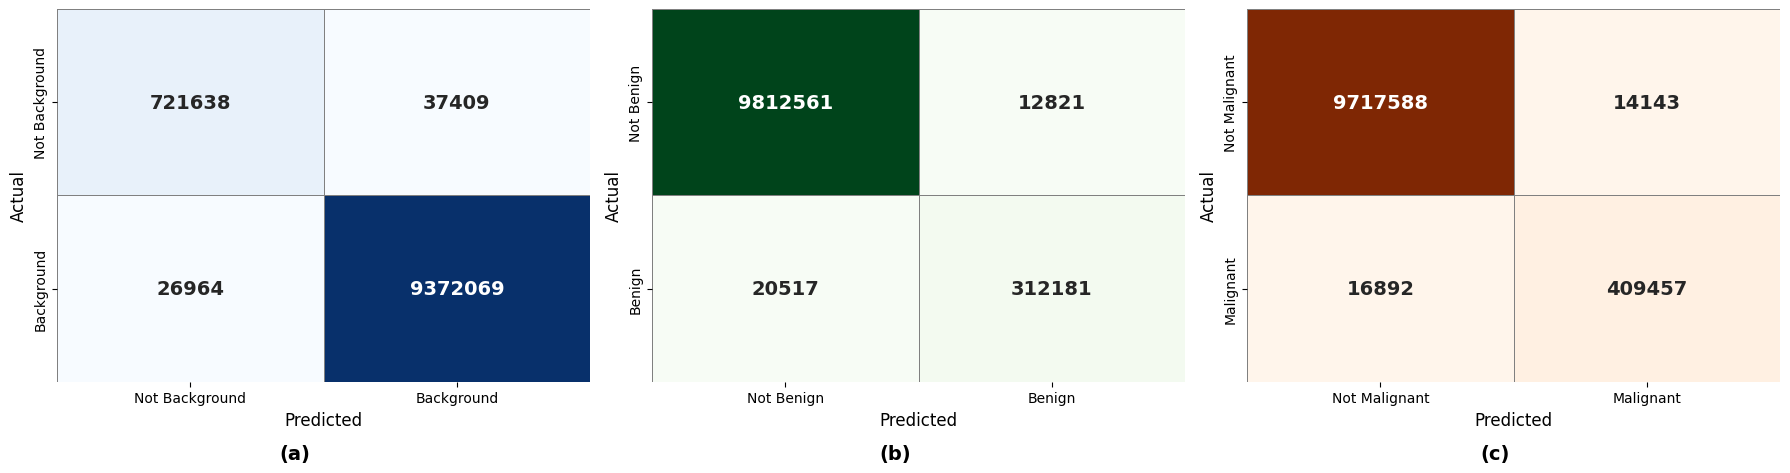

In [16]:
# ===========================================================
# STEP 14a: Confusion Matrix per Class (Side by Side)
# Purpose: # 1. Show binary confusion matrix for each class separately
# 2. Display all three classes (background, benign, malignant) side by side
# ===========================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Flatten predictions for test set
Y_true = np.argmax(Y_test_onehot, axis=-1).flatten()
Y_pred_prob = U_net_model.predict(X_test, batch_size=8)
Y_pred = np.argmax(Y_pred_prob, axis=-1).flatten()

# Classes
class_names = ['Background', 'Benign', 'Malignant']
subplot_labels = ['(a)', '(b)', '(c)']
colors = ['Blues', 'Greens', 'Oranges']  # Different colormap per class

# Create figure with 3 subplots
fig, axes = plt.subplots(1, len(class_names), figsize=(18,5))

for i, cls in enumerate(class_names):
    # Binary labels for one-vs-rest
    y_true_bin = (Y_true == i).astype(int)
    y_pred_bin = (Y_pred == i).astype(int)

    # Confusion matrix
    cm = confusion_matrix(y_true_bin, y_pred_bin)

    # Heatmap with enhanced aesthetics
    sns.heatmap(cm, annot=True, fmt='d', cmap=colors[i],
                xticklabels=[f'Not {cls}', cls],
                yticklabels=[f'Not {cls}', cls],
                cbar=False,
                linewidths=0.5,
                linecolor='gray',
                annot_kws={"size":14, "weight":"bold"},
                ax=axes[i])
    axes[i].set_xlabel('Predicted', fontsize=12)
    axes[i].set_ylabel('Actual', fontsize=12)
    axes[i].set_title('')  # remove title

# Add (a), (b), (c) below each subplot
for i, label in enumerate(subplot_labels):
    x_pos = (i + 0.5) / len(class_names)  # normalized coordinates
    fig.text(x_pos, 0.02, label, ha='center', fontsize=14, fontweight='bold')

# Optional main figure title
# fig.suptitle('Confusion Matrices for Test Set (One-vs-Rest)', fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step


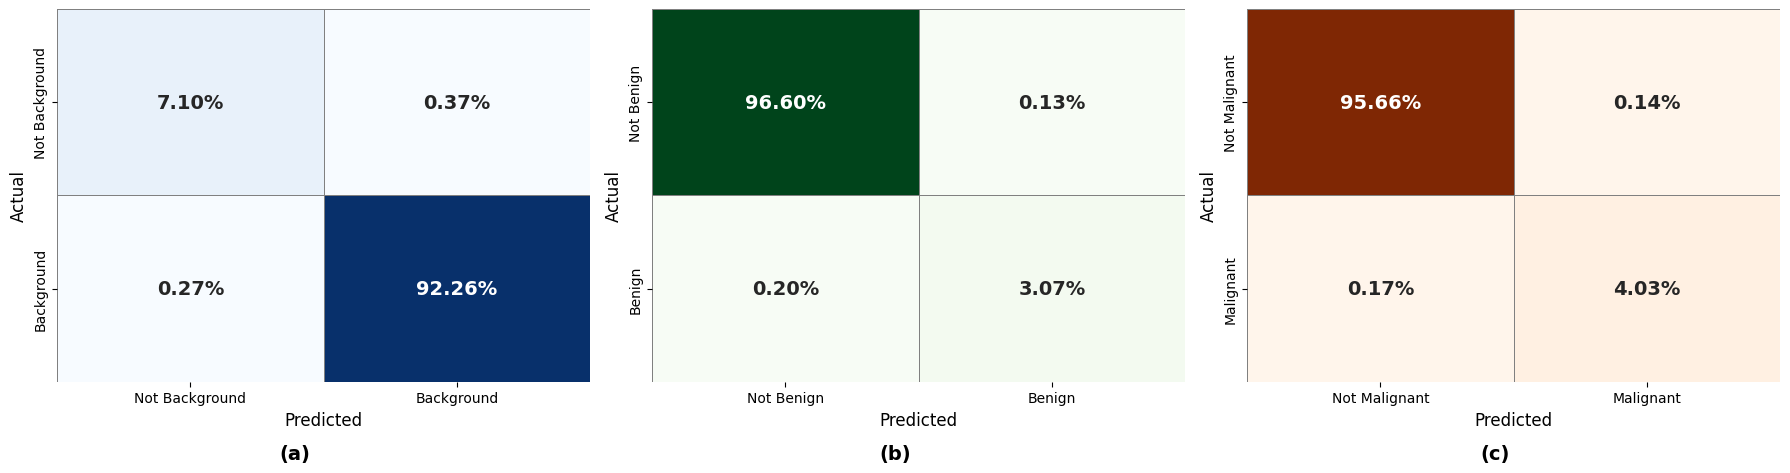

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Flatten predictions for test set
Y_true = np.argmax(Y_test_onehot, axis=-1).flatten()
Y_pred_prob = U_net_model.predict(X_test, batch_size=8)
Y_pred = np.argmax(Y_pred_prob, axis=-1).flatten()

# Classes
class_names = ['Background', 'Benign', 'Malignant']
subplot_labels = ['(a)', '(b)', '(c)']
colors = ['Blues', 'Greens', 'Oranges']

# Create figure
fig, axes = plt.subplots(1, len(class_names), figsize=(18,5))

for i, cls in enumerate(class_names):
    # Binary labels for one-vs-rest
    y_true_bin = (Y_true == i).astype(int)
    y_pred_bin = (Y_pred == i).astype(int)

    # Confusion matrix
    cm = confusion_matrix(y_true_bin, y_pred_bin)

    # Compute percentages
    cm_percent = cm.astype('float') / cm.sum() * 100
    # Format as string with % symbol
    cm_percent_str = np.array([["{0:.2f}%".format(val) for val in row] for row in cm_percent])

    # Plot heatmap
    sns.heatmap(cm_percent, annot=cm_percent_str, fmt='', cmap=colors[i],
                xticklabels=[f'Not {cls}', cls],
                yticklabels=[f'Not {cls}', cls],
                cbar=False,
                linewidths=0.5,
                linecolor='gray',
                annot_kws={"size":14, "weight":"bold"},
                ax=axes[i])

    axes[i].set_xlabel('Predicted', fontsize=12)
    axes[i].set_ylabel('Actual', fontsize=12)
    axes[i].set_title('')  # remove title

# Add (a), (b), (c) below each subplot
for i, label in enumerate(subplot_labels):
    x_pos = (i + 0.5) / len(class_names)  # normalized coordinates
    fig.text(x_pos, 0.02, label, ha='center', fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()



20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step


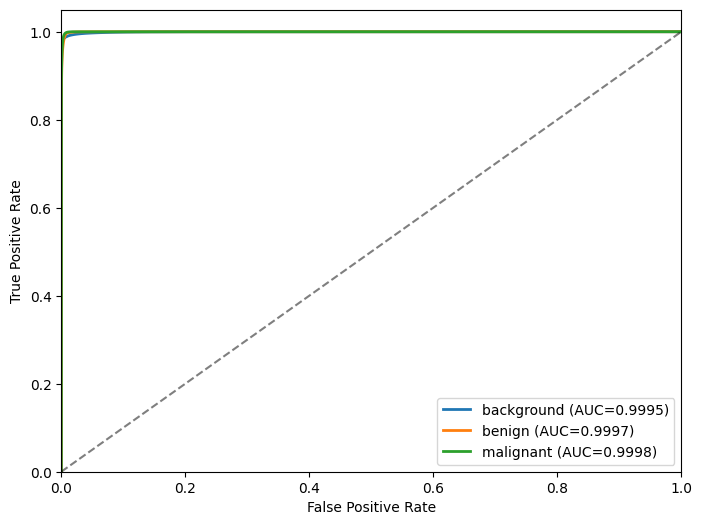

In [18]:
# ===========================================================
# STEP 14k: Per-Class ROC-AUC Curves
# ===========================================================
# Purpose:
# 1. Plot one-vs-rest ROC curves for each class (background, benign, malignant)
# 2. Include AUC in the legend
# 3. Include diagonal reference line (dotted)
# ===========================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

# Flatten true labels
Y_true_flat = np.argmax(Y_test_onehot, axis=-1).flatten()
# Predict probabilities
Y_pred_prob = U_net_model.predict(X_test, batch_size=8)

# Define class names
class_names = ['background', 'benign', 'malignant']

# Initialize dictionaries to store ROC info
fpr_dict = {}
tpr_dict = {}
auc_dict = {}

# Compute ROC per class
for i, cls in enumerate(class_names):
    y_true_bin = (Y_true_flat == i).astype(int)            # True binary labels for class
    y_pred_prob_cls = Y_pred_prob[..., i].flatten()        # Predicted probabilities for class

    try:
        fpr, tpr, _ = roc_curve(y_true_bin, y_pred_prob_cls)
        roc_auc = auc(fpr, tpr)
    except ValueError:
        fpr, tpr, roc_auc = None, None, np.nan
        print(f"Cannot compute ROC for class '{cls}' (not enough positive samples)")

    fpr_dict[cls] = fpr
    tpr_dict[cls] = tpr
    auc_dict[cls] = roc_auc

# Plot all per-class ROC curves
plt.figure(figsize=(8,6))

for cls in class_names:
    if fpr_dict[cls] is not None:
        plt.plot(fpr_dict[cls], tpr_dict[cls], label=f'{cls} (AUC={auc_dict[cls]:.4f})', linewidth=2)

# Diagonal reference line
plt.plot([0,1],[0,1],'k--', alpha=0.5, label='_nolegend_')

# Axes, title, legend
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# plt.title('Per-Class ROC-AUC Curves')
plt.legend(loc='lower right')
plt.show()


In [19]:
from google.colab import drive
drive.mount('/content/drive')

# Save the trained model to Google Drive
model_save_path = '/content/drive/MyDrive/Colab Notebooks/best_trained_unet_model.keras'
U_net_model.save(model_save_path)
print(f"✅ Model saved permanently at: {model_save_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model saved permanently at: /content/drive/MyDrive/Colab Notebooks/best_trained_unet_model.keras


In [86]:
# ===========================================================
# STEP: Load Saved U-Net Model
# ===========================================================

from tensorflow.keras.models import load_model

# Path to the saved model (update if your path is different)
model_load_path = '/content/drive/MyDrive/Colab Notebooks/best_trained_unet_model.keras'

# Load the trained U-Net model
U_net_model = load_model(model_load_path, compile=True)


print("✅ Trained U-Net model loaded successfully!")
U_net_model.summary()


✅ Trained U-Net model loaded successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │      9,248 │ activation_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128,  │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_4[0][0]  

 Total params: 37,707,755 (143.84 MB)

 Trainable params: 12,566,307 (47.94 MB)

 Non-trainable params: 8,832 (34.50 KB)

 Optimizer params: 25,132,616 (95.87 MB)

In [87]:
# ===========================================================
# STEP 15: Generate Predicted Masks with Trained U-Net
# ===========================================================

import numpy as np

# Predict on training, validation, and test sets
Y_train_pred = U_net_model.predict(X_train, batch_size=8)
Y_val_pred   = U_net_model.predict(X_val, batch_size=8)
Y_test_pred  = U_net_model.predict(X_test, batch_size=8)

# Convert predicted probabilities to class labels
Y_train_pred_class = np.argmax(Y_train_pred, axis=-1)  # shape: (n_samples, 256, 256)
Y_val_pred_class   = np.argmax(Y_val_pred, axis=-1)
Y_test_pred_class  = np.argmax(Y_test_pred, axis=-1)

# Quick sanity check
print("Train predictions shape:", Y_train_pred_class.shape)
print("Validation predictions shape:", Y_val_pred_class.shape)
print("Test predictions shape:", Y_test_pred_class.shape)




71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 212ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step
Train predictions shape: (562, 256, 256)
Validation predictions shape: (63, 256, 256)
Test predictions shape: (155, 256, 256)


In [88]:
# ===========================================================
# STEP 16: Extract Morphology Features from U-Net Masks
# ===========================================================

import pandas as pd
import cv2
from skimage.measure import label, regionprops

def extract_morphology_features(images, masks):
    """
    images: original grayscale images (H, W, 1)
    masks: predicted class masks (H, W) with 0=background, 1=benign, 2=malignant
    returns: DataFrame of morphology features per sample
    """
    feature_list = []

    for i in range(len(images)):
        img = images[i].squeeze()    # original grayscale image
        mask = masks[i]              # predicted class mask

        # Extract tumor mask (ignore background)
        tumor_mask = (mask > 0).astype(np.uint8)

        # Skip if no tumor detected
        if np.sum(tumor_mask) == 0:
            feature_list.append({
                "area": 0,
                "perimeter": 0,
                "circularity": 0,
                "solidity": 0,
                "centroid_x": np.nan,
                "centroid_y": np.nan
            })
            continue

        # Label connected components
        labeled_mask = label(tumor_mask)
        props = regionprops(labeled_mask)

        # Take largest component
        largest_region = max(props, key=lambda x: x.area)

        area = largest_region.area
        perimeter = largest_region.perimeter
        circularity = 4 * np.pi * area / (perimeter**2 + 1e-6)
        solidity = largest_region.solidity
        centroid_y, centroid_x = largest_region.centroid

        feature_list.append({
            "area": area,
            "perimeter": perimeter,
            "circularity": circularity,
            "solidity": solidity,
            "centroid_x": centroid_x,
            "centroid_y": centroid_y
        })

    return pd.DataFrame(feature_list)

# Extract features for all datasets
train_features = extract_morphology_features(X_train, Y_train_pred_class)
val_features   = extract_morphology_features(X_val, Y_val_pred_class)
test_features  = extract_morphology_features(X_test, Y_test_pred_class)

# Quick check
print(train_features.head())


      area   perimeter  circularity  solidity  centroid_x  centroid_y
0   2799.0  223.438600     0.704525  0.970527   57.379421   93.450518
1  13559.0  548.700577     0.565935  0.874436  101.487794  126.828822
2   1411.0  156.124892     0.727432  0.956610  145.352232   57.798724
3    838.0  111.154329     0.852317  0.958810  168.236277   52.853222
4  13582.0  566.215295     0.532366  0.860601  156.861802  124.898910


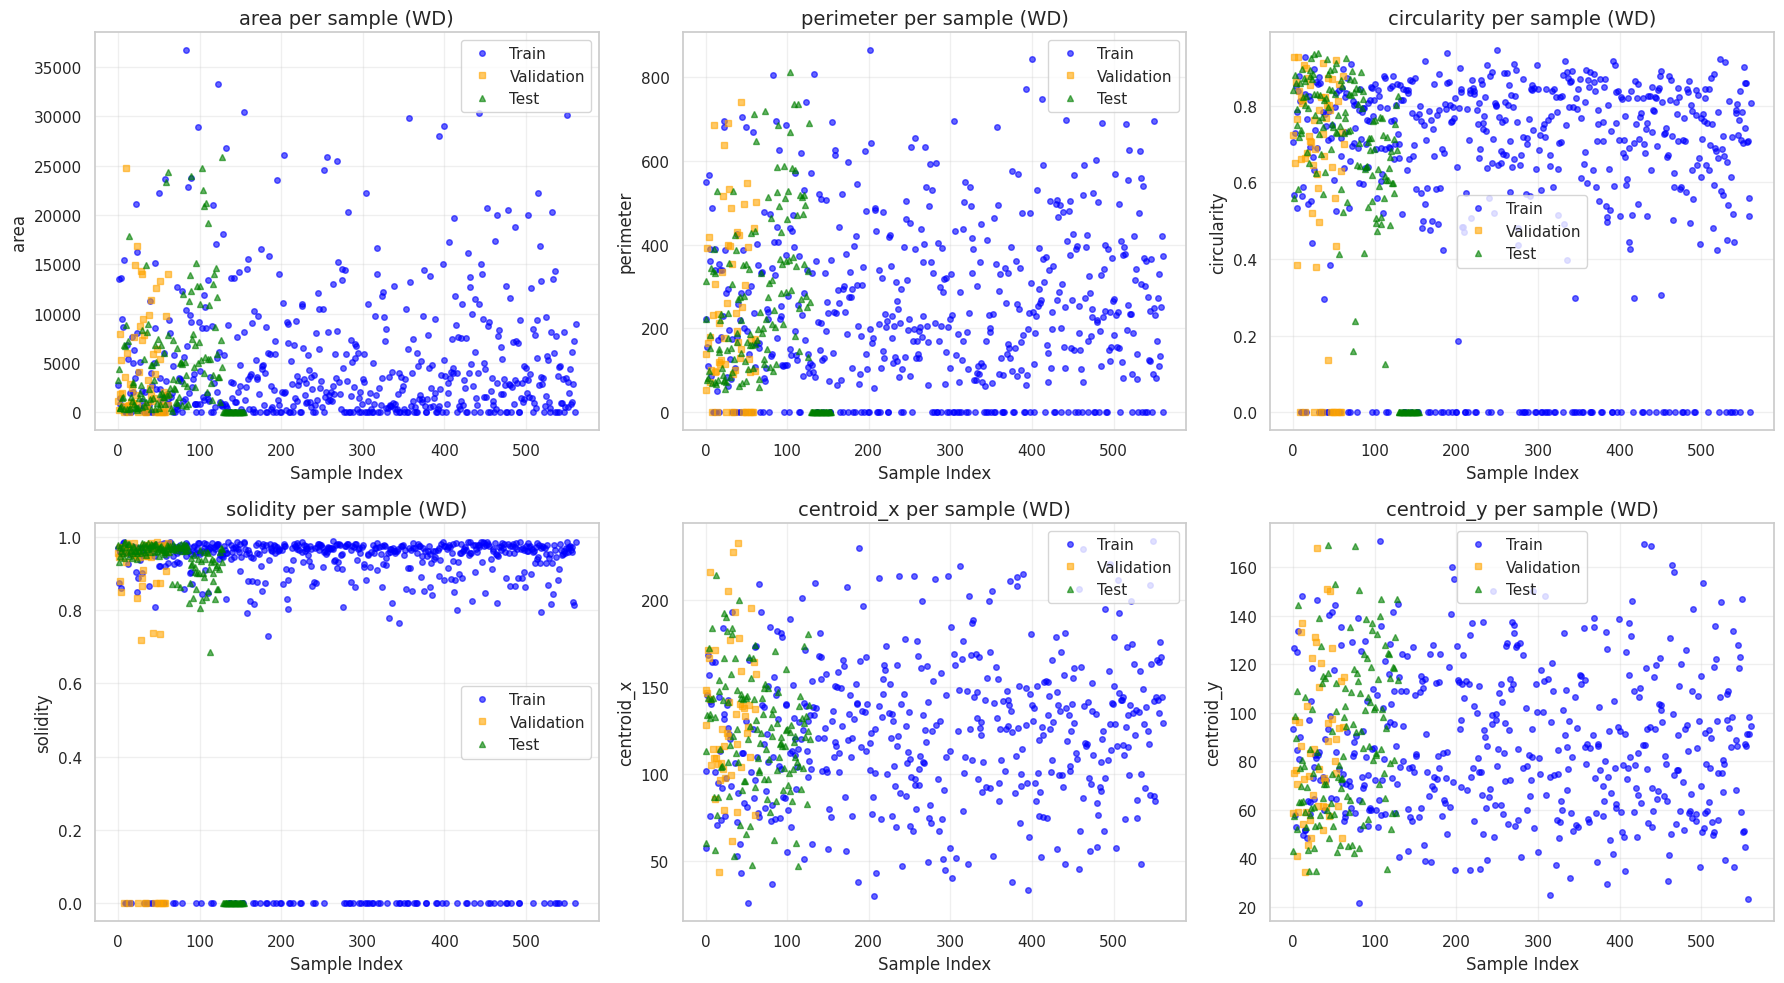

In [89]:
# ===========================================================
# STEP 16c: Plot Morphology Feature Values per Sample (WD)
# ===========================================================

import matplotlib.pyplot as plt

features_to_plot = ['area', 'perimeter', 'circularity', 'solidity', 'centroid_x', 'centroid_y']

# Colors for each split
colors = {
    'Train': 'blue',
    'Val': 'orange',
    'Test': 'green'
}

plt.figure(figsize=(18, 10))

for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 3, i + 1)

    # Plot Train
    plt.plot(
        train_features[feature].values,
        marker='o', linestyle='', markersize=4,
        color=colors['Train'], alpha=0.6, label='Train'
    )

    # Plot Validation
    plt.plot(
        val_features[feature].values,
        marker='s', linestyle='', markersize=4,
        color=colors['Val'], alpha=0.6, label='Validation'
    )

    # Plot Test
    plt.plot(
        test_features[feature].values,
        marker='^', linestyle='', markersize=4,
        color=colors['Test'], alpha=0.6, label='Test'
    )

    plt.xlabel('Sample Index', fontsize=12)
    plt.ylabel(feature, fontsize=12)
    plt.title(f'{feature} per sample (WD)', fontsize=14)
    plt.legend()
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [90]:
# ===========================================================
# STEP 1: Imports + sanity checks (WD morphology regression)
# Requires:
#   train_features, val_features, test_features
# from STEP 16 (morphology extraction)
# ===========================================================

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Morphology features we will use as inputs
feature_cols = ["area", "perimeter", "circularity", "solidity", "centroid_x", "centroid_y"]

for name, df in [("train_features", train_features), ("val_features", val_features), ("test_features", test_features)]:
    missing = [c for c in feature_cols if c not in df.columns]
    print(name, "shape:", df.shape, "missing:", missing)

print("✅ Ready for LSTM regression (WD).")


train_features shape: (562, 6) missing: []
val_features shape: (63, 6) missing: []
test_features shape: (155, 6) missing: []
✅ Ready for LSTM regression (WD).


In [91]:
# ===========================================================
# STEP 2: Build X and Y for multi-target regression
# Targets: area, perimeter, circularity, solidity, centroid_x, centroid_y
# (You can change target_cols if needed)
# ===========================================================

target_cols = ["area", "perimeter", "circularity", "solidity", "centroid_x", "centroid_y"]

X_train_2d = train_features[feature_cols].values.astype(np.float64)
X_val_2d   = val_features[feature_cols].values.astype(np.float64)
X_test_2d  = test_features[feature_cols].values.astype(np.float64)

y_train_2d = train_features[target_cols].values.astype(np.float64)
y_val_2d   = val_features[target_cols].values.astype(np.float64)
y_test_2d  = test_features[target_cols].values.astype(np.float64)

print("X shapes:", X_train_2d.shape, X_val_2d.shape, X_test_2d.shape)
print("y shapes:", y_train_2d.shape, y_val_2d.shape, y_test_2d.shape)


X shapes: (562, 6) (63, 6) (155, 6)
y shapes: (562, 6) (63, 6) (155, 6)


In [92]:
# ===========================================================
# STEP 3: Replace NaN/Inf in X and y with column medians
# ===========================================================

def replace_nan_inf_with_col_median(arr2d):
    arr2d = arr2d.copy()
    col_median = np.nanmedian(arr2d, axis=0)

    inds_nan = np.isnan(arr2d)
    inds_inf = np.isinf(arr2d)

    if inds_nan.any():
        arr2d[inds_nan] = np.take(col_median, np.where(inds_nan)[1])
    if inds_inf.any():
        arr2d[inds_inf] = np.take(col_median, np.where(inds_inf)[1])

    return arr2d

X_train_2d = replace_nan_inf_with_col_median(X_train_2d)
X_val_2d   = replace_nan_inf_with_col_median(X_val_2d)
X_test_2d  = replace_nan_inf_with_col_median(X_test_2d)

y_train_2d = replace_nan_inf_with_col_median(y_train_2d)
y_val_2d   = replace_nan_inf_with_col_median(y_val_2d)
y_test_2d  = replace_nan_inf_with_col_median(y_test_2d)

print("✅ NaN/Inf handled in X and y.")


✅ NaN/Inf handled in X and y.


In [93]:
# ===========================================================
# STEP 4: Log1p transform selected targets (optional but helps)
# We'll log1p only on area and perimeter (usually large scale).
# Circularity/solidity are already in [0,1], centroids are moderate.
# ===========================================================

log_cols = ["area", "perimeter"]  # edit if you want

log_idx = [target_cols.index(c) for c in log_cols]

def apply_log1p_on_cols(y2d, idxs):
    y2d = y2d.copy()
    y2d[:, idxs] = np.log1p(np.maximum(y2d[:, idxs], 0.0))
    return y2d

y_train_log = apply_log1p_on_cols(y_train_2d, log_idx)
y_val_log   = apply_log1p_on_cols(y_val_2d, log_idx)
y_test_log  = apply_log1p_on_cols(y_test_2d, log_idx)

print("✅ Log1p applied to:", log_cols)


✅ Log1p applied to: ['area', 'perimeter']


In [94]:
# ===========================================================
# STEP 5: Standardize X and y (fit on train only)
# ===========================================================

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_2d)
X_val_scaled   = scaler_X.transform(X_val_2d)
X_test_scaled  = scaler_X.transform(X_test_2d)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train_log)
y_val_scaled   = scaler_y.transform(y_val_log)
y_test_scaled  = scaler_y.transform(y_test_log)

print("✅ Standardization done.")
print("X_train_scaled:", X_train_scaled.shape)
print("y_train_scaled:", y_train_scaled.shape)


✅ Standardization done.
X_train_scaled: (562, 6)
y_train_scaled: (562, 6)


In [95]:
# ===========================================================
# STEP 6: Reshape for LSTM (timesteps=1)
# ===========================================================

X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_val_lstm   = X_val_scaled.reshape(X_val_scaled.shape[0], 1, X_val_scaled.shape[1])
X_test_lstm  = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

n_features = X_train_lstm.shape[2]
n_targets  = y_train_scaled.shape[1]

print("✅ LSTM input shape:", X_train_lstm.shape)
print("Targets:", n_targets, target_cols)


✅ LSTM input shape: (562, 1, 6)
Targets: 6 ['area', 'perimeter', 'circularity', 'solidity', 'centroid_x', 'centroid_y']


In [96]:
# ===========================================================
# STEP 7: Build LSTM multi-target regression model
# ===========================================================

tf.keras.backend.clear_session()

inp = Input(shape=(1, n_features), name="morph_input")

x = LSTM(64, activation="tanh", return_sequences=False)(inp)
x = Dropout(0.3)(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.2)(x)

out = Dense(n_targets, activation="linear", name="morph_regression")(x)

lstm_reg_model = Model(inp, out)
lstm_reg_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=["mae", "mse"]
)

lstm_reg_model.summary()
print("✅ LSTM regression model compiled.")


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ morph_input (InputLayer)        │ (None, 1, 6)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ morph_regression (Dense)        │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,726 (88.77 KB)

 Trainable params: 22,726 (88.77 KB)

 Non-trainable params: 0 (0.00 B)

✅ LSTM regression model compiled.


In [97]:
# ===========================================================
# STEP 8: Train
# ===========================================================

callbacks = [
    EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-6, verbose=1)
]

history = lstm_reg_model.fit(
    X_train_lstm, y_train_scaled,
    validation_data=(X_val_lstm, y_val_scaled),
    epochs=150,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

print("✅ LSTM regression trained.")


Epoch 1/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.9600 - mae: 0.7364 - mse: 0.9600 - val_loss: 0.6460 - val_mae: 0.5954 - val_mse: 0.6460 - learning_rate: 0.0010
Epoch 2/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4805 - mae: 0.5117 - mse: 0.4805 - val_loss: 0.1943 - val_mae: 0.3148 - val_mse: 0.1943 - learning_rate: 0.0010
Epoch 3/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1805 - mae: 0.3061 - mse: 0.1805 - val_loss: 0.0721 - val_mae: 0.1889 - val_mse: 0.0721 - learning_rate: 0.0010
Epoch 4/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0933 - mae: 0.2267 - mse: 0.0933 - val_loss: 0.0397 - val_mae: 0.1402 - val_mse: 0.0397 - learning_rate: 0.0010
Epoch 5/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0749 - mae: 0.2115 - mse: 0.0749 - val_loss: 0.0276 - val_mae: 0.1116 - val_mse: 0.0276 - learning_rate: 0.0010
Epoch 6/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0816 - mae: 0.2180 - mse: 0.0816 - val_loss: 0.0274 - val_mae: 0.1218 - v

In [98]:
# ===========================================================
# STEP 9: Predict + inverse transform back to original scale
# ===========================================================

y_pred_scaled = lstm_reg_model.predict(X_test_lstm, verbose=0)

# Inverse standardization
y_pred_log = scaler_y.inverse_transform(y_pred_scaled)
y_true_log = scaler_y.inverse_transform(y_test_scaled)

# Undo log1p for selected columns
def undo_log1p_on_cols(y2d, idxs):
    y2d = y2d.copy()
    y2d[:, idxs] = np.expm1(y2d[:, idxs])
    return y2d

y_pred = undo_log1p_on_cols(y_pred_log, log_idx)
y_true = undo_log1p_on_cols(y_true_log, log_idx)

print("✅ Predictions transformed back to original scale.")
print("y_pred shape:", y_pred.shape)


✅ Predictions transformed back to original scale.
y_pred shape: (155, 6)


In [99]:
# ===========================================================
# STEP 10: Print regression results per target (MAE, MSE, RMSE, R2)
# ===========================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

results = []

for j, col in enumerate(target_cols):
    yt = y_true[:, j]
    yp = y_pred[:, j]

    mae = mean_absolute_error(yt, yp)
    mse = mean_squared_error(yt, yp)
    rmse = float(np.sqrt(mse))
    r2 = r2_score(yt, yp)

    results.append([col, mae, mse, rmse, r2])

results_df = pd.DataFrame(results, columns=["target", "MAE", "MSE", "RMSE", "R2"])
print(results_df.to_string(index=False))

print("\n✅ First 10 predictions (per target):")
for j, col in enumerate(target_cols):
    print(col, "pred:", np.round(y_pred[:10, j], 4), "true:", np.round(y_true[:10, j], 4))


     target        MAE          MSE        RMSE       R2
       area 791.663293 2.755164e+06 1659.868651 0.924293
  perimeter  16.802602 9.174945e+02   30.290171 0.977298
circularity   0.016562 7.145261e-04    0.026731 0.992190
   solidity   0.018849 8.196366e-04    0.028629 0.993501
 centroid_x   2.021104 8.017745e+00    2.831562 0.991432
 centroid_y   1.588798 6.086181e+00    2.467019 0.992751

✅ First 10 predictions (per target):
area pred: [2410.988  4121.1025  639.538   658.3131  811.5226 1610.1879 2205.713
 6770.9434  534.8912 6410.8643] true: [3314. 4334.  419.  453.  621. 1388. 1563. 6815.  340. 6663.]
perimeter pred: [211.3136 290.2215  90.0317  92.7165 111.491  148.0026 188.3883 358.8241
  86.2984 345.6565] true: [222.6934 312.2203  77.3553  81.3553  99.2548 152.468  183.7817 345.3209
  70.5269 337.0782]
circularity pred: [0.8153 0.5902 0.8647 0.8593 0.8043 0.7716 0.6287 0.7264 0.8411 0.7443] true: [0.8397 0.5587 0.8799 0.8601 0.7921 0.7503 0.5815 0.7182 0.859  0.7369]
solidi

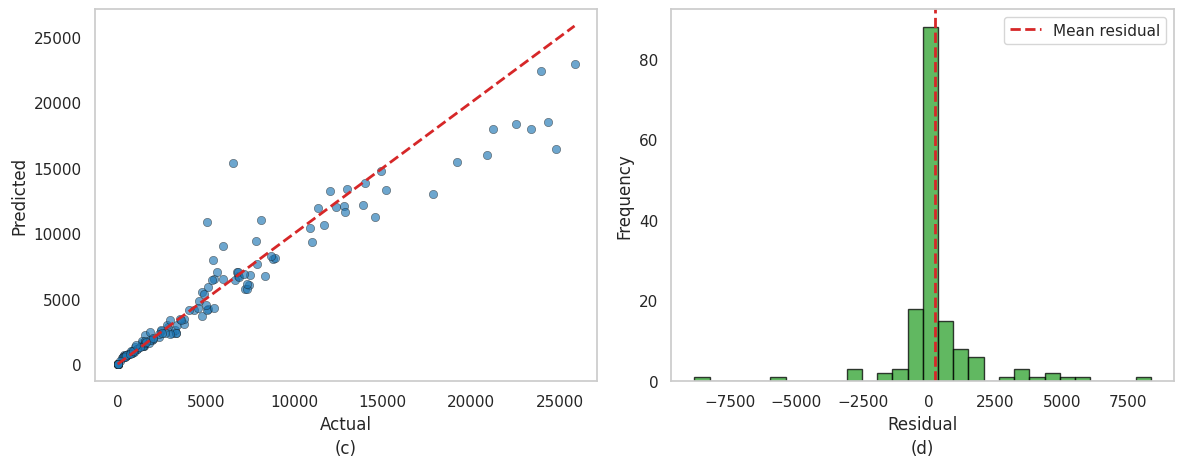

In [100]:
# ===========================================================
# STEP 11: Optional plots (Actual vs Predicted + Residuals) for ONE target
# Choose a target to visualise (default: area)
# ===========================================================

import matplotlib.pyplot as plt

target_to_plot = "area"  # change if you want
j = target_cols.index(target_to_plot)

yt = y_true[:, j]
yp = y_pred[:, j]
residuals = yt - yp

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1) Actual vs Predicted
axes[0].scatter(
    yt, yp,
    color="tab:blue",
    alpha=0.65,
    edgecolors="k",
    linewidths=0.4
)

mn = float(min(yt.min(), yp.min()))
mx = float(max(yt.max(), yp.max()))

axes[0].plot(
    [mn, mx], [mn, mx],
    color="tab:red",
    linestyle="--",
    linewidth=2
)

axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[0].grid(False)

# 2) Residuals distribution
axes[1].hist(
    residuals,
    bins=30,
    color="tab:green",
    alpha=0.75,
    edgecolor="black"
)

axes[1].axvline(
    residuals.mean(),
    color="tab:red",
    linestyle="--",
    linewidth=2,
    label="Mean residual"
)

axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].legend()
axes[1].grid(False)

# Adjust layout to make room for labels
plt.tight_layout()
plt.subplots_adjust(bottom=0.22)

# Add panel labels under each subplot
axes[0].text(
    0.5, -0.18, "(c)",
    ha="center", va="center",
    transform=axes[0].transAxes
)

axes[1].text(
    0.5, -0.18, "(d)",
    ha="center", va="center",
    transform=axes[1].transAxes
)

plt.show()


In [101]:
import numpy as np
import pandas as pd

# Choose target
target_name = "area"
j = target_cols.index(target_name)

y_true_cont = y_true[:, j]
y_pred_cont = y_pred[:, j]

# Define tolerance (e.g., 10% of true value or fixed value)
tol = 0.1 * np.mean(y_true_cont)  # you can change this

# Build categories: -1 = under, 0 = ok, +1 = over
diff = y_pred_cont - y_true_cont

y_err_class = np.zeros_like(diff, dtype=int)
y_err_class[diff < -tol] = -1   # under-estimate
y_err_class[diff >  tol] =  1   # over-estimate

# Count results
labels = ["Under", "OK", "Over"]
counts = pd.Series(y_err_class).value_counts().sort_index()

print("Error category counts for", target_name)
for k, name in zip([-1, 0, 1], labels):
    print(f"{name:5s}:", counts.get(k, 0))


Error category counts for area
Under: 35
OK   : 104
Over : 16


In [105]:
# ===========================================================
# STEP: Print MSE, MAE, RMSE, R² for WD LSTM Regression
# ===========================================================

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Overall metrics (averaged over all targets and samples)
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print("📊 Regression Performance (WODD, all targets combined):")
print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")



📊 Regression Performance (WODD, all targets combined):
MAE : 135.3519
MSE : 459349.2562
RMSE: 677.7531
R²  : 0.9786


array([[<Axes: title={'center': 'area'}>,
        <Axes: title={'center': 'circularity'}>]], dtype=object)

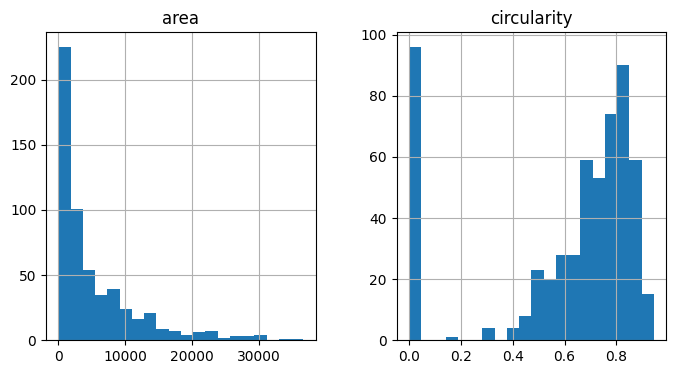

In [23]:
train_features[['area', 'circularity']].hist(bins=20, figsize=(8,4))


In [ ]:
train_features = extract_morphology_features(X_train, Y_train_pred_class)


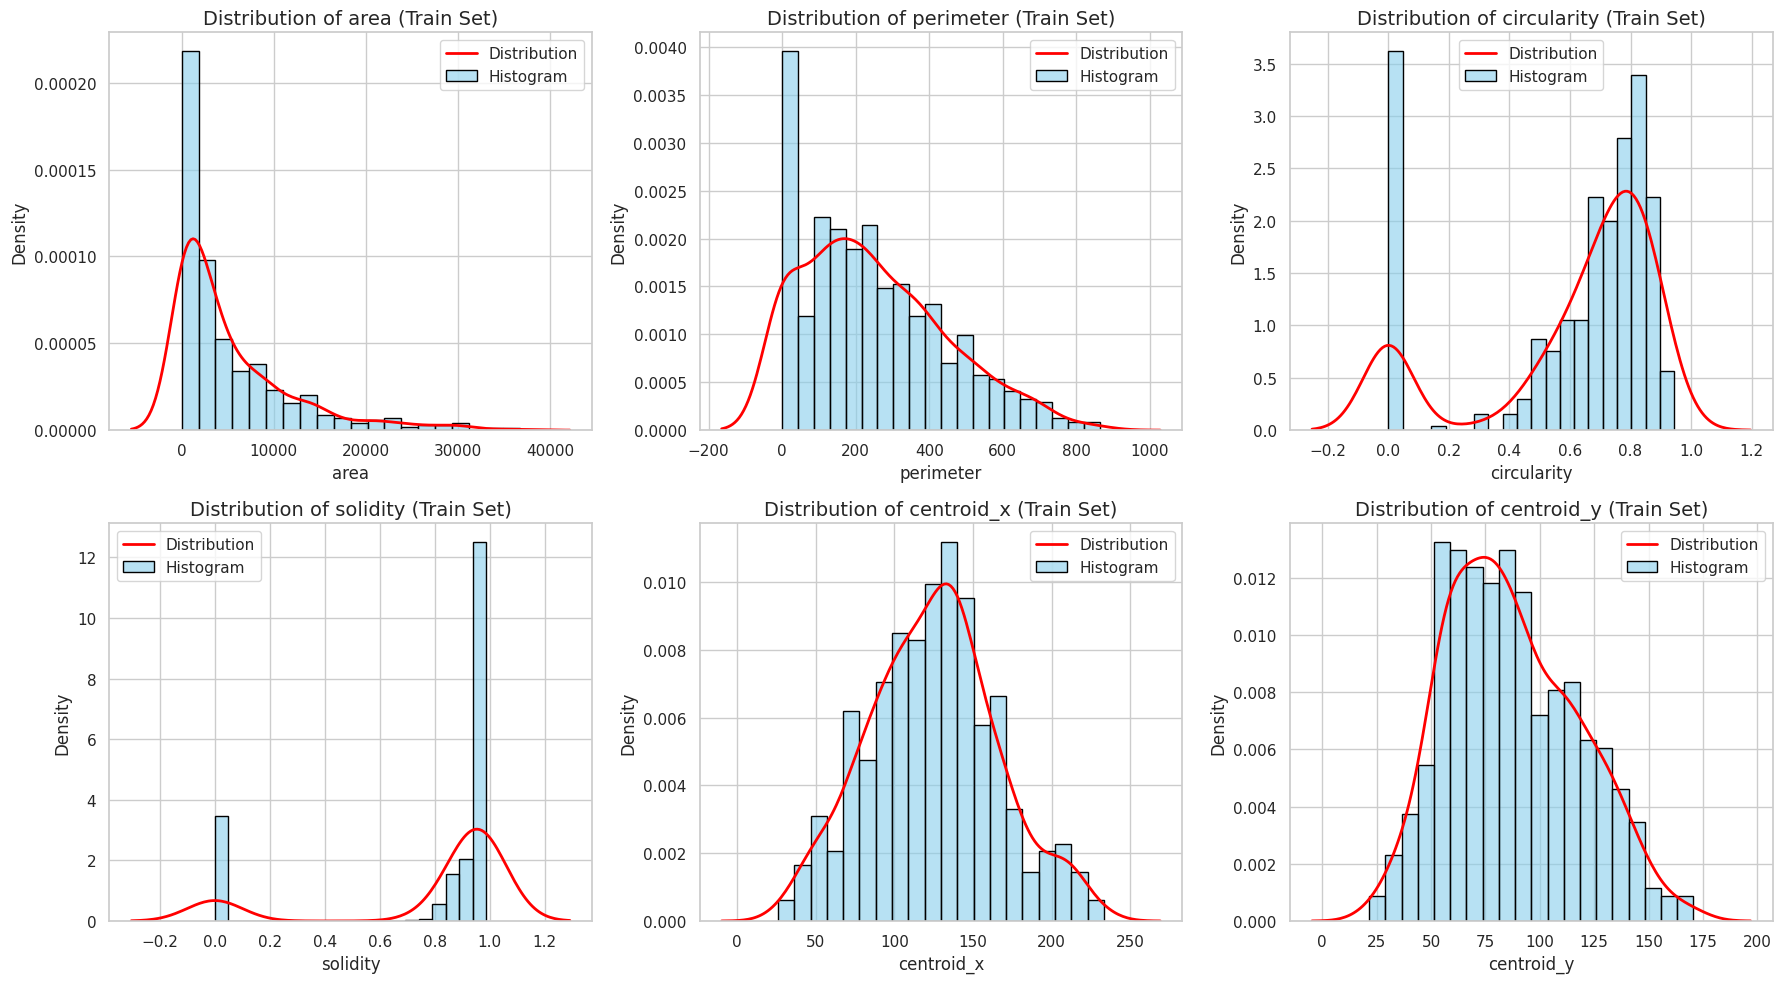

In [24]:
# ===========================================================
# STEP 16b: Plot Morphology Feature Distributions with KDE
# ===========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Features to plot
features_to_plot = ['area', 'perimeter', 'circularity', 'solidity', 'centroid_x', 'centroid_y']

# Set Seaborn style
sns.set(style="whitegrid")

plt.figure(figsize=(18, 10))

for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 3, i+1)

    # Plot histogram
    sns.histplot(train_features[feature], bins=20, color='skyblue',
                 edgecolor='black', stat='density', alpha=0.6, label='Histogram')

    # Plot KDE curve
    sns.kdeplot(train_features[feature], color='red', linewidth=2, label='Distribution')

    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.title(f'Distribution of {feature} (Train Set)', fontsize=14)
    plt.legend()

plt.tight_layout()
plt.show()


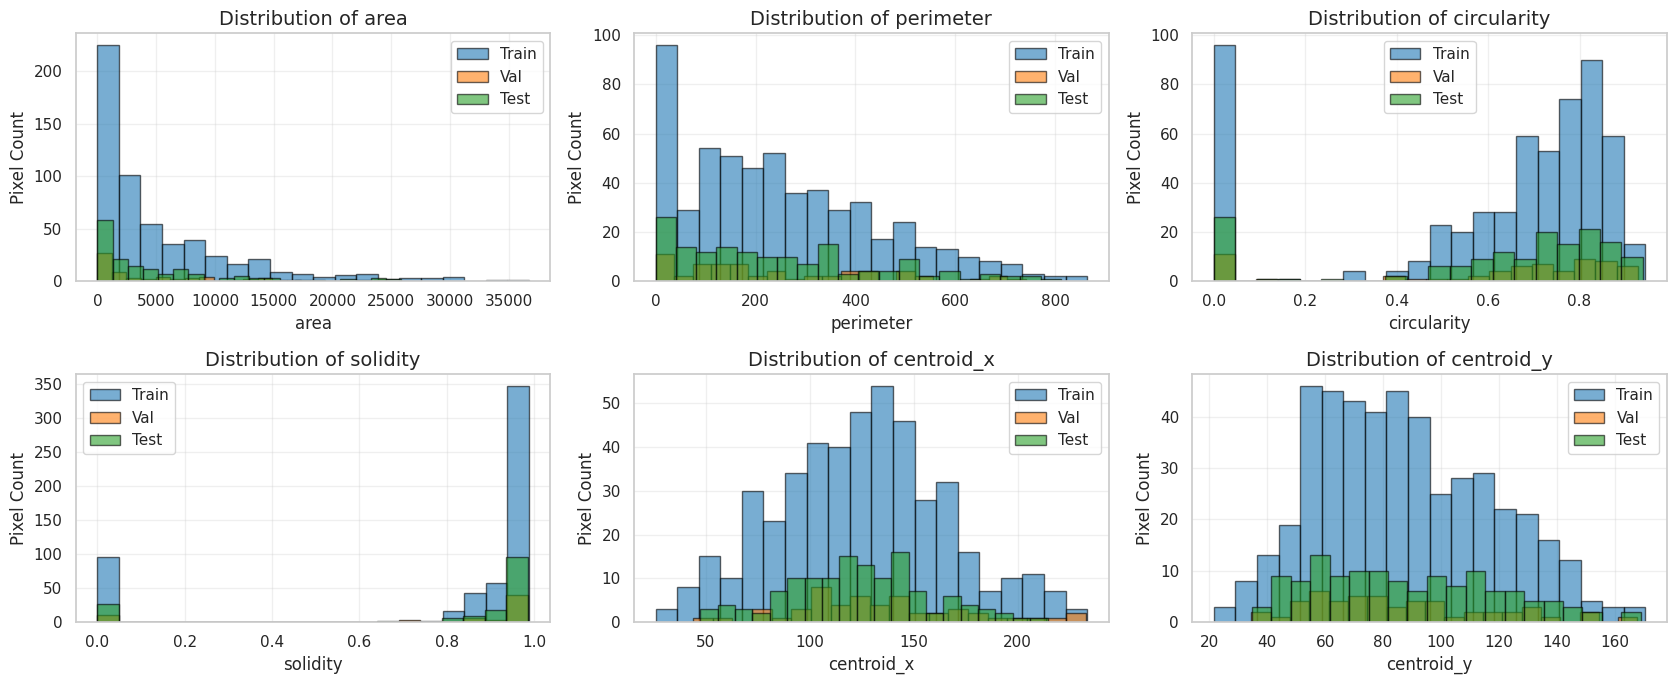

In [25]:
# ===========================================================
# Step: Colorful Morphology Feature Histograms
# ===========================================================

import matplotlib.pyplot as plt

features_to_plot = ['area', 'perimeter', 'circularity', 'solidity', 'centroid_x', 'centroid_y']

# Define custom colors for each dataset
colors = {
    'Train': '#1f77b4',  # blue
    'Val':   '#ff7f0e',  # orange
    'Test':  '#2ca02c'   # green
}

plt.figure(figsize=(17, 7))

for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 3, i+1)

    # Plot Train, Val, Test with transparency
    plt.hist(train_features[feature], bins=20, alpha=0.6, color=colors['Train'], edgecolor='black', label='Train')
    plt.hist(val_features[feature], bins=20, alpha=0.6, color=colors['Val'], edgecolor='black', label='Val')
    plt.hist(test_features[feature], bins=20, alpha=0.6, color=colors['Test'], edgecolor='black', label='Test')

    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Pixel Count', fontsize=12)
    plt.title(f'Distribution of {feature}', fontsize=14)
    plt.legend()
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()



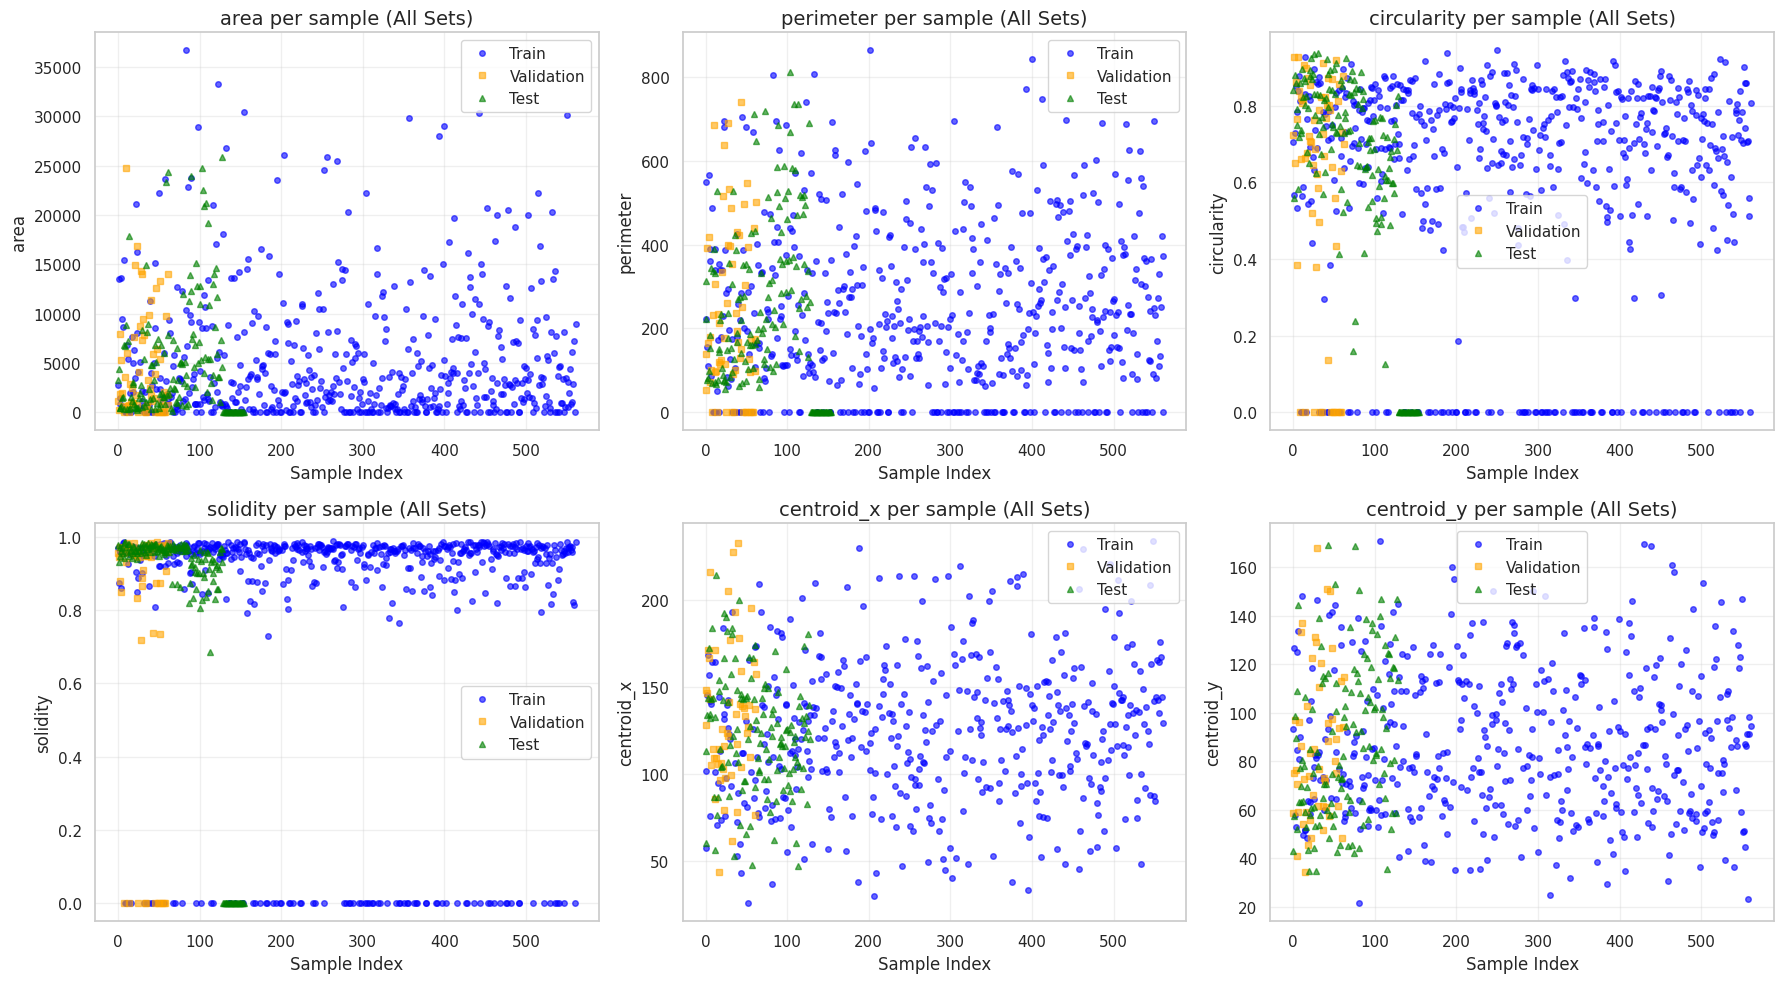

In [26]:
# ===========================================================
# STEP 16c: Feature Values per Sample for Train / Val / Test
# ===========================================================

import matplotlib.pyplot as plt

features_to_plot = ['area', 'perimeter', 'circularity', 'solidity', 'centroid_x', 'centroid_y']

# Define colors for each dataset
colors = {
    'Train': 'blue',
    'Val': 'orange',
    'Test': 'green'
}

plt.figure(figsize=(18, 10))

for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 3, i+1)

    # Plot Train
    plt.plot(train_features[feature].values, marker='o', linestyle='', markersize=4,
             color=colors['Train'], alpha=0.6, label='Train')

    # Plot Validation
    plt.plot(val_features[feature].values, marker='s', linestyle='', markersize=4,
             color=colors['Val'], alpha=0.6, label='Validation')

    # Plot Test
    plt.plot(test_features[feature].values, marker='^', linestyle='', markersize=4,
             color=colors['Test'], alpha=0.6, label='Test')

    plt.xlabel('Sample Index', fontsize=12)
    plt.ylabel(feature, fontsize=12)
    plt.title(f'{feature} per sample (All Sets)', fontsize=14)
    plt.legend()
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()



In [27]:
# ===========================================================
# STEP 17a (Fixed): Prepare LSTM Input and Output
# ===========================================================

import numpy as np

# -----------------------------
# Add regression target: delta_area
train_features['delta_area'] = train_features['area'].values
val_features['delta_area']   = val_features['area'].values
test_features['delta_area']  = test_features['area'].values

# -----------------------------
# Add classification target: malignancy (0=benign, 1=malignant)
train_features['malignancy'] = (Y_train_pred_class > 1).any(axis=(1,2)).astype(int)
val_features['malignancy']   = (Y_val_pred_class > 1).any(axis=(1,2)).astype(int)
test_features['malignancy']  = (Y_test_pred_class > 1).any(axis=(1,2)).astype(int)

# -----------------------------
# Features to use for LSTM
feature_cols = ['area', 'perimeter', 'circularity', 'solidity', 'centroid_x', 'centroid_y']

# LSTM input shape: (samples, timesteps, features)
X_train_lstm = np.expand_dims(train_features[feature_cols].values, axis=1)
X_val_lstm   = np.expand_dims(val_features[feature_cols].values, axis=1)
X_test_lstm  = np.expand_dims(test_features[feature_cols].values, axis=1)

# -----------------------------
# Targets
y_reg_train = train_features['delta_area'].values
y_reg_val   = val_features['delta_area'].values
y_reg_test  = test_features['delta_area'].values

y_class_train = train_features['malignancy'].values
y_class_val   = val_features['malignancy'].values
y_class_test  = test_features['malignancy'].values

# -----------------------------
# Quick check
print("✅ LSTM Inputs and Outputs Prepared")
print("X_train_lstm shape:", X_train_lstm.shape)
print("X_val_lstm shape:", X_val_lstm.shape)
print("X_test_lstm shape:", X_test_lstm.shape)
print("y_reg_train shape:", y_reg_train.shape)
print("y_class_train shape:", y_class_train.shape)


✅ LSTM Inputs and Outputs Prepared
X_train_lstm shape: (562, 1, 6)
X_val_lstm shape: (63, 1, 6)
X_test_lstm shape: (155, 1, 6)
y_reg_train shape: (562,)
y_class_train shape: (562,)


In [28]:
# ===========================================================
# STEP 17b: Build Multi-Task LSTM Network
# ===========================================================
# Purpose:
# 1. LSTM network for morphology features
# 2. Multi-task outputs:
#    - Regression: Δarea
#    - Classification: malignancy
# 3. Compile with appropriate losses and metrics
# ===========================================================

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

# -----------------------------
# Input layer: morphology features
n_features = X_train_lstm.shape[2]  # 6 features
input_layer = Input(shape=(1, n_features), name='morph_input')

# -----------------------------
# LSTM layers
x = LSTM(64, activation='tanh', return_sequences=False)(input_layer)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.2)(x)

# -----------------------------
# Regression output: Δarea
reg_output = Dense(1, activation='linear', name='regression_output')(x)

# Classification output: malignancy
class_output = Dense(1, activation='sigmoid', name='classification_output')(x)

# -----------------------------
# Define model
lstm_model = Model(inputs=input_layer, outputs=[reg_output, class_output])

# -----------------------------
# Compile model
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss={
        'regression_output': 'mse',         # Regression loss
        'classification_output': 'binary_crossentropy'  # Classification loss
    },
    metrics={
        'regression_output': ['mae', 'mse'],
        'classification_output': ['accuracy', tf.keras.metrics.Precision(name='precision'),
                                  tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')]
    }
)

# -----------------------------
# Summary
lstm_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ morph_input         │ (None, 1, 6)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     18,176 │ morph_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 64)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      2,080 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ regression_output   │ (None, 1)         │         33 │ dropout_9[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification_out… │ (None, 1)         │         33 │ dropout_9[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,322 (79.38 KB)

 Trainable params: 20,322 (79.38 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# ===========================================================
# STEP 1: Scale Regression Targets for LSTM (Fixed)
# ===========================================================

from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Ensure y_reg_* are numpy arrays and 2D
y_reg_train = np.array(y_reg_train).reshape(-1, 1)
y_reg_val   = np.array(y_reg_val).reshape(-1, 1)
y_reg_test  = np.array(y_reg_test).reshape(-1, 1)

# Initialize scaler
scaler_y = MinMaxScaler(feature_range=(0, 1))

# Fit scaler on training regression target
y_reg_train_scaled = scaler_y.fit_transform(y_reg_train)

# Transform validation and test targets using the same scaler
y_reg_val_scaled   = scaler_y.transform(y_reg_val)
y_reg_test_scaled  = scaler_y.transform(y_reg_test)

print("✅ Step 1 completed: Regression targets scaled to range [0,1].")
print(f"Sample scaled training targets:\n{y_reg_train_scaled[:5]}")


✅ Step 1 completed: Regression targets scaled to range [0,1].
Sample scaled training targets:
[[0.07625872]
 [0.36941478]
 [0.03844268]
 [0.0228313 ]
 [0.37004141]]


In [30]:
# ===========================================================
# STEP 2: Prepare LSTM Input in 3D Format
# ===========================================================

import numpy as np

# Convert feature DataFrames / arrays to numpy arrays if needed
X_train_array = np.array(X_train_lstm)
X_val_array   = np.array(X_val_lstm)
X_test_array  = np.array(X_test_lstm)

# Add time dimension to make 3D input: (samples, timesteps, features)
# Here, timesteps=1 for single-step sequences
X_train_lstm_3d = np.expand_dims(X_train_array, axis=1)  # shape -> [samples, 1, features]
X_val_lstm_3d   = np.expand_dims(X_val_array, axis=1)
X_test_lstm_3d  = np.expand_dims(X_test_array, axis=1)

# Confirm shapes
print("✅ Step 2 completed: LSTM inputs prepared in 3D format.")
print(f"X_train shape: {X_train_lstm_3d.shape}")
print(f"X_val shape: {X_val_lstm_3d.shape}")
print(f"X_test shape: {X_test_lstm_3d.shape}")

# Number of features
n_features = X_train_lstm_3d.shape[2]
print(f"Number of features for LSTM input: {n_features}")


✅ Step 2 completed: LSTM inputs prepared in 3D format.
X_train shape: (562, 1, 1, 6)
X_val shape: (63, 1, 1, 6)
X_test shape: (155, 1, 1, 6)
Number of features for LSTM input: 1


In [31]:
# ===========================================================
# STEP 3: Define LSTM Model
# ===========================================================

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense

# Define LSTM input shape: (timesteps, features)
lstm_input = Input(shape=(1, n_features), name='lstm_input')  # timesteps=1 for single-step sequences

# LSTM layer
x = LSTM(64, activation='tanh', name='lstm_layer')(lstm_input)

# -----------------------------
# Regression output: predicts tumor growth
regression_output = Dense(1, activation='linear', name='regression_output')(x)

# Classification output: predicts malignancy
classification_output = Dense(1, activation='sigmoid', name='classification_output')(x)

# -----------------------------
# Build model
lstm_model = Model(inputs=lstm_input, outputs=[regression_output, classification_output])

# Compile model with appropriate losses and metrics
lstm_model.compile(
    optimizer='adam',
    loss={
        'regression_output': 'mse',
        'classification_output': 'binary_crossentropy'
    },
    metrics={
        'regression_output': ['mae', 'mse'],
        'classification_output': ['accuracy', 'Precision', 'Recall', 'AUC']
    }
)

# Confirm model summary
lstm_model.summary()
print("✅ Step 3 completed: LSTM model defined and compiled.")


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ lstm_input          │ (None, 1, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_layer (LSTM)   │ (None, 64)        │     16,896 │ lstm_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ regression_output   │ (None, 1)         │         65 │ lstm_layer[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification_out… │ (None, 1)         │         65 │ lstm_layer[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 17,026 (66.51 KB)

 Trainable params: 17,026 (66.51 KB)

 Non-trainable params: 0 (0.00 B)

✅ Step 3 completed: LSTM model defined and compiled.


In [32]:
# ===========================================================
# STEP 4: Define Callbacks for LSTM Training
# ===========================================================

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# 1️⃣ Save best model based on validation AUC of classification output
checkpoint_lstm = ModelCheckpoint(
    filepath='/content/drive/MyDrive/Colab Notebooks/best_lstm_model.keras',
    monitor='val_classification_output_AUC',
    save_best_only=True,
    mode='max',
    verbose=1
)

# 2️⃣ Early stopping to avoid overfitting
early_stop_lstm = EarlyStopping(
    monitor='val_classification_output_AUC',
    patience=15,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

# 3️⃣ Reduce learning rate when validation AUC plateaus
reduce_lr_lstm = ReduceLROnPlateau(
    monitor='val_classification_output_AUC',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    mode='max',
    verbose=1
)

print("✅ Step 4 completed: Callbacks defined for checkpointing, early stopping, and LR reduction.")


✅ Step 4 completed: Callbacks defined for checkpointing, early stopping, and LR reduction.


In [33]:
# ===========================================================
# STABLE PIPELINE: Preprocessing + Dense Network Training
# ===========================================================

import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# -----------------------------
# 0️⃣ Clear previous TF session
# -----------------------------
K.clear_session()
print("✅ Cleared previous TensorFlow session.")

# -----------------------------
# 1️⃣ Clean input features (X)
# -----------------------------
# Convert to 2D if needed
X_train_2d = X_train_lstm.reshape(X_train_lstm.shape[0], -1)
X_val_2d   = X_val_lstm.reshape(X_val_lstm.shape[0], -1)
X_test_2d  = X_test_lstm.reshape(X_test_lstm.shape[0], -1)

# Replace NaNs/Infs in features with column median
for arr in [X_train_2d, X_val_2d, X_test_2d]:
    col_median = np.nanmedian(arr, axis=0)
    inds_nan = np.isnan(arr)
    inds_inf = np.isinf(arr)
    arr[inds_nan] = np.take(col_median, np.where(inds_nan)[1])
    arr[inds_inf] = np.take(col_median, np.where(inds_inf)[1])

print("✅ NaNs/Infs in input features handled.")

# -----------------------------
# 2️⃣ Standardize features
# -----------------------------
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_2d)
X_val_scaled   = scaler_X.transform(X_val_2d)
X_test_scaled  = scaler_X.transform(X_test_2d)

n_features = X_train_scaled.shape[1]
print(f"✅ Features standardized. Number of features: {n_features}")

# -----------------------------
# 3️⃣ Clean regression target
# -----------------------------
# Replace NaNs/Infs
y_reg_train = np.array(y_reg_train).reshape(-1,1)
y_reg_val   = np.array(y_reg_val).reshape(-1,1)
y_reg_test  = np.array(y_reg_test).reshape(-1,1)

for arr in [y_reg_train, y_reg_val, y_reg_test]:
    if np.isnan(arr).any() or np.isinf(arr).any():
        median_val = np.nanmedian(arr)
        arr[np.isnan(arr)] = median_val
        arr[np.isinf(arr)] = median_val

# Optional: log-transform if values span wide range
y_reg_train_log = np.log1p(y_reg_train)
y_reg_val_log   = np.log1p(y_reg_val)
y_reg_test_log  = np.log1p(y_reg_test)

# Standardize regression target
scaler_y = StandardScaler()
y_reg_train_scaled = scaler_y.fit_transform(y_reg_train_log)
y_reg_val_scaled   = scaler_y.transform(y_reg_val_log)
y_reg_test_scaled  = scaler_y.transform(y_reg_test_log)

print("✅ Regression target cleaned, log-transformed, and scaled.")

# -----------------------------
# 4️⃣ Clean classification target
# -----------------------------
y_class_train = np.array(y_class_train).reshape(-1,1)
y_class_val   = np.array(y_class_val).reshape(-1,1)
y_class_test  = np.array(y_class_test).reshape(-1,1)

# Ensure 0/1 and finite
y_class_train[np.isnan(y_class_train)] = 0
y_class_val[np.isnan(y_class_val)] = 0
y_class_test[np.isnan(y_class_test)] = 0

y_class_train[y_class_train>1] = 1
y_class_val[y_class_val>1] = 1
y_class_test[y_class_test>1] = 1

print("✅ Classification target cleaned.")

# -----------------------------
# 5️⃣ Define callbacks
# -----------------------------
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

# -----------------------------
# 6️⃣ Train Dense network for regression
# -----------------------------
inputs = Input(shape=(n_features,))
x = Dense(16, activation='relu')(inputs)
x = Dense(16, activation='relu')(x)
regression_output = Dense(1, activation='linear')(x)

reg_model = Model(inputs, regression_output)
reg_model.compile(optimizer=Adam(1e-4), loss='mse', metrics=['mae','mse'])

reg_history = reg_model.fit(
    X_train_scaled, y_reg_train_scaled,
    validation_data=(X_val_scaled, y_reg_val_scaled),
    epochs=100,
    batch_size=8,
    callbacks=callbacks,
    verbose=1
)
print("✅ Regression network trained successfully.")

# -----------------------------
# 7️⃣ Train Dense network for classification
# -----------------------------
x2 = Dense(16, activation='relu')(inputs)
x2 = Dense(16, activation='relu')(x2)
classification_output = Dense(1, activation='sigmoid')(x2)

class_model = Model(inputs, classification_output)
class_model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy',
                    metrics=['accuracy','Precision','Recall','AUC'])

class_history = class_model.fit(
    X_train_scaled, y_class_train,
    validation_data=(X_val_scaled, y_class_val),
    epochs=100,
    batch_size=8,
    callbacks=callbacks,
    verbose=1
)
print("✅ Classification network trained successfully.")


✅ Cleared previous TensorFlow session.
✅ NaNs/Infs in input features handled.
✅ Features standardized. Number of features: 6
✅ Regression target cleaned, log-transformed, and scaled.
✅ Classification target cleaned.
Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 1.0821 - mae: 0.9188 - mse: 1.0821 - val_loss: 0.9740 - val_mae: 0.8511 - val_mse: 0.9740 - learning_rate: 1.0000e-04
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0022 - mae: 0.8742 - mse: 1.0022 - val_loss: 0.8258 - val_mae: 0.7799 - val_mse: 0.8258 - learning_rate: 1.0000e-04
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7998 - mae: 0.7759 - mse: 0.7998 - val_loss: 0.7107 - val_mae: 0.7206 - val_mse: 0.7107 - learning_rate: 1.0000e-04
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7083 - mae: 0.7273 - mse: 0.7083 - val_loss: 0.6156 - val_mae: 0.6688 - val_mse: 0.6156 - learning_rate: 1.0000e-04
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6269 - mae: 0.

In [34]:
from tensorflow.keras import backend as K

# Clear previous TF session
K.clear_session()
print("✅ Cleared previous TensorFlow session.")


✅ Cleared previous TensorFlow session.


In [35]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Reshape to 2D
X_train_2d = X_train_lstm.reshape(X_train_lstm.shape[0], -1)
X_val_2d   = X_val_lstm.reshape(X_val_lstm.shape[0], -1)
X_test_2d  = X_test_lstm.reshape(X_test_lstm.shape[0], -1)

# Replace NaN / Inf with column median
for arr in [X_train_2d, X_val_2d, X_test_2d]:
    col_median = np.nanmedian(arr, axis=0)
    inds_nan = np.isnan(arr)
    inds_inf = np.isinf(arr)
    arr[inds_nan] = np.take(col_median, np.where(inds_nan)[1])
    arr[inds_inf] = np.take(col_median, np.where(inds_inf)[1])

# Standardize
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_2d)
X_val_scaled   = scaler_X.transform(X_val_2d)
X_test_scaled  = scaler_X.transform(X_test_2d)

n_features = X_train_scaled.shape[1]
print(f"✅ Features standardized. Number of features: {n_features}")


✅ Features standardized. Number of features: 6


In [36]:
# Ensure 2D
y_reg_train = np.array(y_reg_train).reshape(-1,1)
y_reg_val   = np.array(y_reg_val).reshape(-1,1)
y_reg_test  = np.array(y_reg_test).reshape(-1,1)

# Replace NaN/Inf
for arr in [y_reg_train, y_reg_val, y_reg_test]:
    median_val = np.nanmedian(arr)
    arr[np.isnan(arr)] = median_val
    arr[np.isinf(arr)] = median_val

# Log-transform
y_reg_train_log = np.log1p(y_reg_train)
y_reg_val_log   = np.log1p(y_reg_val)
y_reg_test_log  = np.log1p(y_reg_test)

# Standardize
from sklearn.preprocessing import StandardScaler
scaler_y = StandardScaler()
y_reg_train_scaled = scaler_y.fit_transform(y_reg_train_log)
y_reg_val_scaled   = scaler_y.transform(y_reg_val_log)
y_reg_test_scaled  = scaler_y.transform(y_reg_test_log)

print("✅ Regression target preprocessed.")


✅ Regression target preprocessed.


In [37]:
# Ensure 1D array
y_class_train = np.array(y_class_train).reshape(-1,)
y_class_val   = np.array(y_class_val).reshape(-1,)
y_class_test  = np.array(y_class_test).reshape(-1,)

# Clip to 0/1
y_class_train = np.clip(y_class_train, 0, 1)
y_class_val   = np.clip(y_class_val, 0, 1)
y_class_test  = np.clip(y_class_test, 0, 1)

print("✅ Classification target preprocessed.")


✅ Classification target preprocessed.


In [38]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, LeakyReLU

inputs = Input(shape=(n_features,))

# Shared layers
x = Dense(32)(inputs)
x = LeakyReLU(negative_slope=0.1)(x)
x = Dropout(0.2)(x)
x = Dense(32)(x)
x = LeakyReLU(negative_slope=0.1)(x)
x = Dropout(0.2)(x)

# Outputs
regression_output = Dense(1, activation='linear', name='regression')(x)
classification_output = Dense(1, activation='sigmoid', name='classification')(x)

multi_model = Model(inputs=inputs, outputs=[regression_output, classification_output])
multi_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        224 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 32)        │          0 │ dense[0][0]       │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      1,056 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 32)        │          0 │ dense_1[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ leaky_re_lu_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ regression (Dense)  │ (None, 1)         │         33 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification      │ (None, 1)         │         33 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,346 (5.26 KB)

 Trainable params: 1,346 (5.26 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
from tensorflow.keras.optimizers import Adam

multi_model.compile(
    optimizer=Adam(1e-4),
    loss={'regression':'mse', 'classification':'binary_crossentropy'},
    metrics={'regression':['mae','mse'],
             'classification':['accuracy','Precision','Recall','AUC']}
)

print("✅ Multi-output model compiled.")


✅ Multi-output model compiled.


In [40]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1)
]

history = multi_model.fit(
    X_train_scaled,
    {'regression': y_reg_train_scaled, 'classification': y_class_train},
    validation_data=(X_val_scaled, {'regression': y_reg_val_scaled, 'classification': y_class_val}),
    epochs=150,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)
print("✅ Multi-output model trained successfully.")


Epoch 1/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - classification_AUC: 0.4419 - classification_Precision: 0.2555 - classification_Recall: 0.4625 - classification_accuracy: 0.4810 - classification_loss: 0.7147 - loss: 2.0388 - regression_loss: 1.3230 - regression_mae: 0.9389 - regression_mse: 1.3242 - val_classification_AUC: 0.5729 - val_classification_Precision: 0.3529 - val_classification_Recall: 0.7059 - val_classification_accuracy: 0.5714 - val_classification_loss: 0.6828 - val_loss: 1.6381 - val_regression_loss: 0.9611 - val_regression_mae: 0.7860 - val_regression_mse: 0.9550 - learning_rate: 1.0000e-04
Epoch 2/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - classification_AUC: 0.4978 - classification_Precision: 0.2581 - classification_Recall: 0.4327 - classification_accuracy: 0.5238 - classification_loss: 0.7022 - loss: 1.7465 - regression_loss: 1.0446 - regression_mae: 0.8236 - regression_mse: 1.0440 - val_classification_AUC: 0.5742 - val_classification_Precision: 0.3214 - val_cl

In [41]:
# Save in native Keras format
multi_model.save('multi_output_model.keras')
print("✅ Multi-output model saved successfully!")

# Load model
from tensorflow.keras.models import load_model
loaded_model = load_model('multi_output_model.keras')
print("✅ Multi-output model loaded successfully!")


✅ Multi-output model saved successfully!
✅ Multi-output model loaded successfully!


In [42]:
# -----------------------------
# Save models using native Keras format
# -----------------------------
reg_model.save("regression_model.keras")
class_model.save("classification_model.keras")
print("✅ Models saved successfully in .keras format!")

# -----------------------------
# Load models safely
# -----------------------------
from tensorflow.keras.models import load_model

loaded_reg_model = load_model("regression_model.keras")
print("✅ Regression model loaded successfully!")

loaded_class_model = load_model("classification_model.keras")
print("✅ Classification model loaded successfully!")


✅ Models saved successfully in .keras format!
✅ Regression model loaded successfully!
✅ Classification model loaded successfully!


In [43]:
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler



In [44]:
# Load the multi-output model
multi_model = load_model('multi_output_model.keras')
print("✅ Multi-output model loaded successfully!")
multi_model.summary()




✅ Multi-output model loaded successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        224 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 32)        │          0 │ dense[0][0]       │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      1,056 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 32)        │          0 │ dense_1[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ leaky_re_lu_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ regression (Dense)  │ (None, 1)         │         33 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification      │ (None, 1)         │         33 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,040 (15.79 KB)

 Trainable params: 1,346 (5.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,694 (10.53 KB)

In [45]:
# Convert to 2D if needed and replace NaNs/Infs
X_test_2d = X_test_lstm.reshape(X_test_lstm.shape[0], -1)

for arr in [X_test_2d]:
    col_median = np.nanmedian(arr, axis=0)
    inds_nan = np.isnan(arr)
    inds_inf = np.isinf(arr)
    arr[inds_nan] = np.take(col_median, np.where(inds_nan)[1])
    arr[inds_inf] = np.take(col_median, np.where(inds_inf)[1])

# Standardize using previously fitted scaler
X_test_scaled = scaler_X.transform(X_test_2d)
print("✅ Test features preprocessed and scaled.")
                          # undo log1p


✅ Test features preprocessed and scaled.


In [46]:
# Predict both regression and classification outputs
y_pred_reg_scaled, y_pred_class = multi_model.predict(X_test_scaled)

print("✅ Predictions completed.")



5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step
✅ Predictions completed.


In [47]:
# Regression predictions were log-transformed and scaled
y_pred_reg_log = scaler_y.inverse_transform(y_pred_reg_scaled)
y_pred_reg = np.expm1(y_pred_reg_log)  # undo log1p

print("✅ Regression predictions transformed back to original scale.")



✅ Regression predictions transformed back to original scale.


In [48]:
# Classification threshold (default 0.5)
y_pred_class_binary = (y_pred_class >= 0.5).astype(int)

print("✅ Classification predictions binarized.")



✅ Classification predictions binarized.


In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_reg_test, y_pred_reg)
mse = mean_squared_error(y_reg_test, y_pred_reg)
r2  = r2_score(y_reg_test, y_pred_reg)

print(f"Regression Performance:\nMAE: {mae:.4f}, MSE: {mse:.4f}, R2: {r2:.4f}")


Regression Performance:
MAE: 1275.4094, MSE: 8763961.1425, R2: 0.7592


In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

acc   = accuracy_score(y_class_test, y_pred_class_binary)
prec  = precision_score(y_class_test, y_pred_class_binary)
rec   = recall_score(y_class_test, y_pred_class_binary)
f1    = f1_score(y_class_test, y_pred_class_binary)
auc   = roc_auc_score(y_class_test, y_pred_class)

print(f"Classification Performance:\nAccuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")


Classification Performance:
Accuracy: 0.8065, Precision: 0.6757, Recall: 0.5814, F1: 0.6250, AUC: 0.8997


In [51]:
# Print first 10 predictions for quick inspection
print("Regression predictions (first 10):", y_pred_reg[:10].flatten())
print("Classification predictions (first 10):", y_pred_class_binary[:10].flatten())


Regression predictions (first 10): [3142.8713  4070.7869   688.11163  719.23114  677.4221  1132.135
 2053.663   6861.5127   520.436   6690.975  ]
Classification predictions (first 10): [0 0 0 0 0 0 0 0 0 0]


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
import numpy as np


1/5 ━━━━━━━━━━━━━━━━━━━━ 1s 262ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step


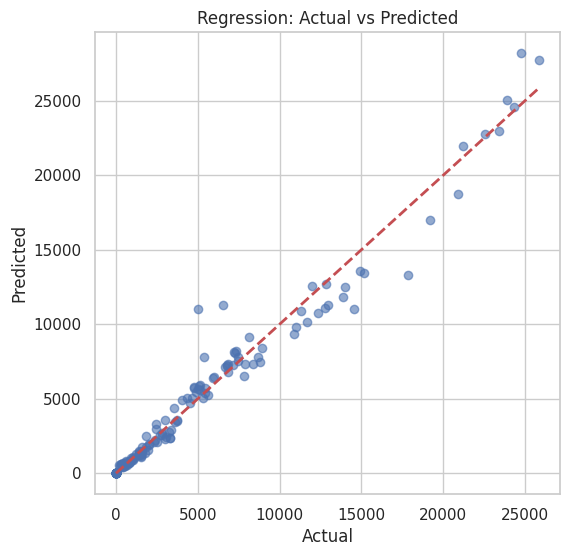

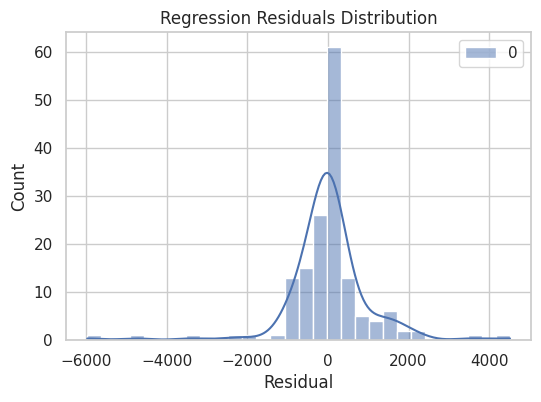

Regression MAE: 566.98, MSE: 1119427.25, R2: 0.9692


In [53]:
# -----------------------------
# Regression Predictions
# -----------------------------
y_pred_reg = loaded_reg_model.predict(X_test_scaled)
y_pred_reg_inv = np.expm1(scaler_y.inverse_transform(y_pred_reg))  # inverse log+scale transform
y_test_inv = np.expm1(scaler_y.inverse_transform(y_reg_test_scaled))

# 1️⃣ Predicted vs Actual
plt.figure(figsize=(6,6))
plt.scatter(y_test_inv, y_pred_reg_inv, alpha=0.6)
plt.plot([y_test_inv.min(), y_test_inv.max()], [y_test_inv.min(), y_test_inv.max()], 'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Regression: Actual vs Predicted")
plt.show()

# 2️⃣ Residuals distribution
residuals = y_test_inv - y_pred_reg_inv
plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Regression Residuals Distribution")
plt.xlabel("Residual")
plt.show()

# 3️⃣ Regression metrics
mae = mean_absolute_error(y_test_inv, y_pred_reg_inv)
mse = mean_squared_error(y_test_inv, y_pred_reg_inv)
r2 = r2_score(y_test_inv, y_pred_reg_inv)
print(f"Regression MAE: {mae:.2f}, MSE: {mse:.2f}, R2: {r2:.4f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


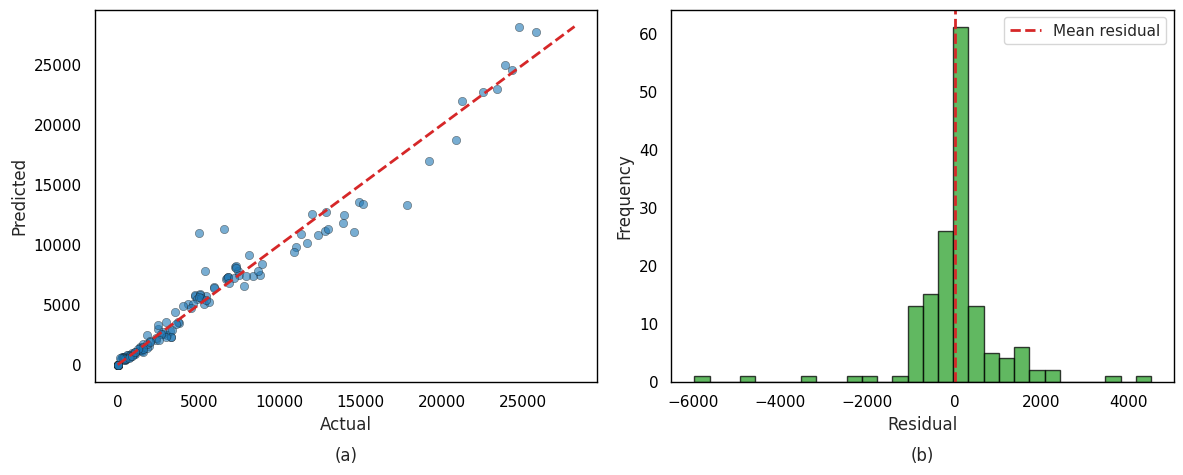

Regression MAE: 566.98
Regression MSE: 1119427.25
Regression R²: 0.9692


In [54]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# Regression Predictions
# -----------------------------
y_pred_reg = loaded_reg_model.predict(X_test_scaled)
y_pred_reg_inv = np.expm1(scaler_y.inverse_transform(y_pred_reg))  # inverse log+scale transform
y_test_inv = np.expm1(scaler_y.inverse_transform(y_reg_test_scaled))

# Residuals
residuals = y_test_inv - y_pred_reg_inv

# -----------------------------
# Side-by-side plots (MATCH LAYOUT)
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Actual vs Predicted
axes[0].scatter(
    y_test_inv,
    y_pred_reg_inv,
    color="tab:blue",
    alpha=0.6,
    edgecolors="k",
    linewidths=0.4
)

mn = float(min(y_test_inv.min(), y_pred_reg_inv.min()))
mx = float(max(y_test_inv.max(), y_pred_reg_inv.max()))

axes[0].plot(
    [mn, mx], [mn, mx],
    color="tab:red",
    linestyle="--",
    linewidth=2
)

axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[0].grid(False)

# Panel label (a) - MATCH POSITION
axes[0].text(0.5, -0.20, "(a)", ha="center", va="center", transform=axes[0].transAxes)

# (b) Residuals distribution
axes[1].hist(
    residuals,
    bins=30,
    color="tab:green",
    alpha=0.75,
    edgecolor="black"
)

axes[1].axvline(
    residuals.mean(),
    color="tab:red",
    linestyle="--",
    linewidth=2,
    label="Mean residual"
)

axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].legend()
axes[1].grid(False)

# Panel label (b) - MATCH POSITION
axes[1].text(0.5, -0.20, "(b)", ha="center", va="center", transform=axes[1].transAxes)

# Match border & ticks style
for ax in axes:
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.0)
    ax.tick_params(axis='both', direction='out', colors='black', length=6, width=1.0)

# MATCH SPACING WITH PREVIOUS FIGURE
plt.tight_layout()
plt.subplots_adjust(bottom=0.22)

plt.show()

# -----------------------------
# Regression metrics
# -----------------------------
mae = mean_absolute_error(y_test_inv, y_pred_reg_inv)
mse = mean_squared_error(y_test_inv, y_pred_reg_inv)
r2 = r2_score(y_test_inv, y_pred_reg_inv)

print(f"Regression MAE: {mae:.2f}")
print(f"Regression MSE: {mse:.2f}")
print(f"Regression R²: {r2:.4f}")


In [66]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

yt = y_test_inv.reshape(-1)
yp = y_pred_reg_inv.reshape(-1)

mae = mean_absolute_error(yt, yp)
mse = mean_squared_error(yt, yp)
rmse = np.sqrt(mse)
r2 = r2_score(yt, yp)

print("📊 Regression Performance (WODD):")
print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")


📊 Regression Performance (WODD):
MAE : 566.9825
MSE : 1119427.2459
RMSE: 1058.0299
R²  : 0.9692


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


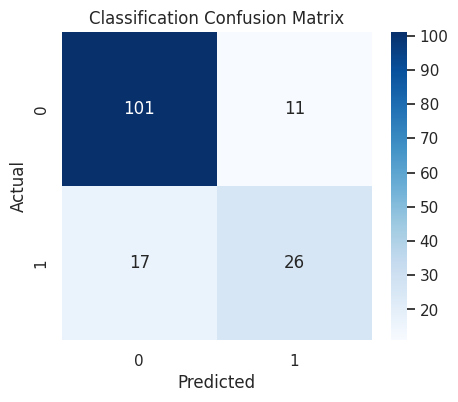

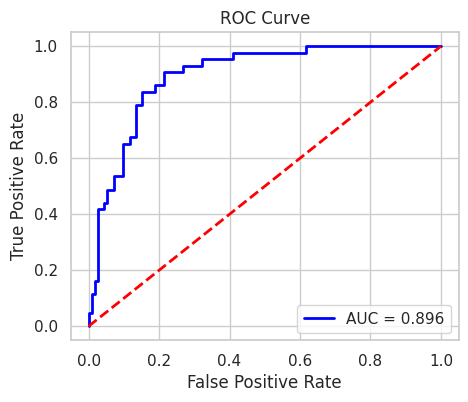

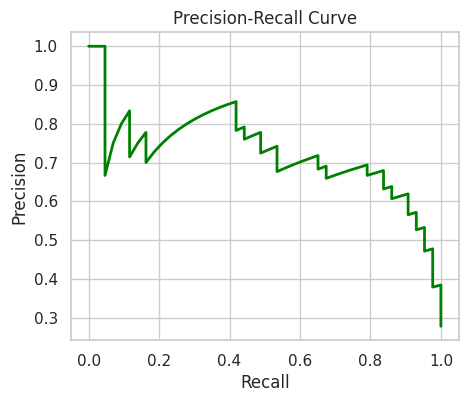

Classification Report:
               precision    recall  f1-score   support

           0     0.8559    0.9018    0.8783       112
           1     0.7027    0.6047    0.6500        43

    accuracy                         0.8194       155
   macro avg     0.7793    0.7532    0.7641       155
weighted avg     0.8134    0.8194    0.8149       155



In [55]:
# -----------------------------
# Classification Predictions
# -----------------------------
y_pred_class_prob = loaded_class_model.predict(X_test_scaled)
y_pred_class = (y_pred_class_prob > 0.5).astype(int)

# 1️⃣ Confusion Matrix
cm = confusion_matrix(y_class_test, y_pred_class)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Classification Confusion Matrix")
plt.show()

# 2️⃣ ROC Curve
fpr, tpr, _ = roc_curve(y_class_test, y_pred_class_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], color='red', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC Curve")
plt.legend(loc='lower right')
plt.show()

# 3️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_class_test, y_pred_class_prob)
plt.figure(figsize=(5,4))
plt.plot(recall, precision, color='green', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title("Precision-Recall Curve")
plt.show()

# 4️⃣ Classification metrics
report = classification_report(y_class_test, y_pred_class, digits=4)
print("Classification Report:\n", report)


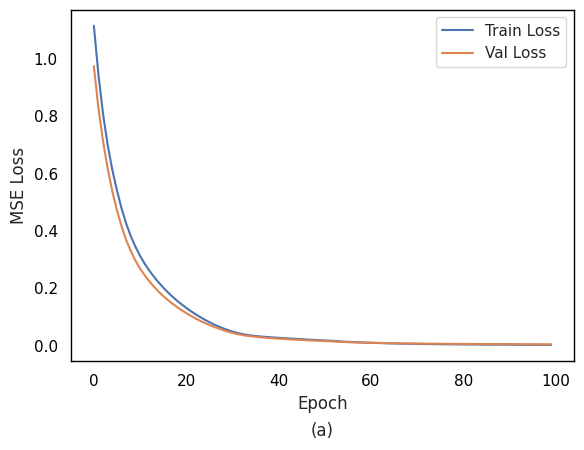

In [56]:
# -----------------------------
# Regression Loss (match border/spines style)
# -----------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4.5))

plt.plot(reg_history.history['loss'], label='Train Loss')
plt.plot(reg_history.history['val_loss'], label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(False)

ax = plt.gca()

# Force consistent dark border (spines)
for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1.0)

# Also force tick colors to black
ax.tick_params(colors="black")

# Panel label "(a)"
plt.text(0.5, -0.20, "(a)", ha="center", va="center", transform=ax.transAxes)

plt.subplots_adjust(bottom=0.28)
plt.tight_layout()
plt.show()


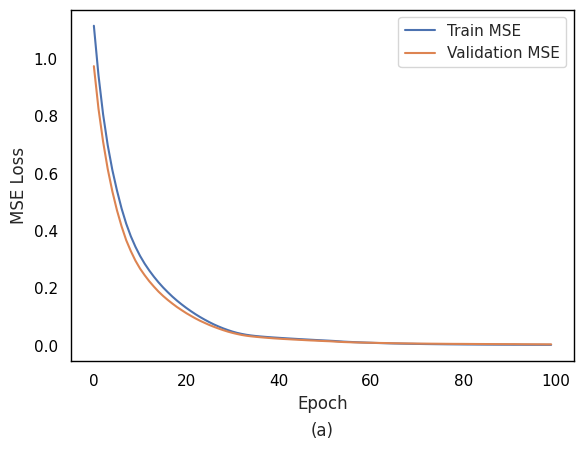

In [57]:
# -----------------------------
# Regression Loss (outer ticks on x and y axes)
# -----------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4.5))

plt.plot(reg_history.history['loss'], label='Train MSE')
plt.plot(reg_history.history['val_loss'], label='Validation MSE')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(False)

ax = plt.gca()

# Force consistent dark border (spines)
for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1.0)

# Make ticks point OUTWARD on both axes
ax.tick_params(
    axis='both',
    which='both',
    direction='out',   # <-- this makes ticks outer
    length=6,
    width=1.0,
    colors='black',
    top=False,
    right=False
)

# Panel label "(a)"
ax.text(0.5, -0.20, "(a)", ha="center", va="center", transform=ax.transAxes)

plt.subplots_adjust(bottom=0.28)
plt.tight_layout()
plt.show()


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


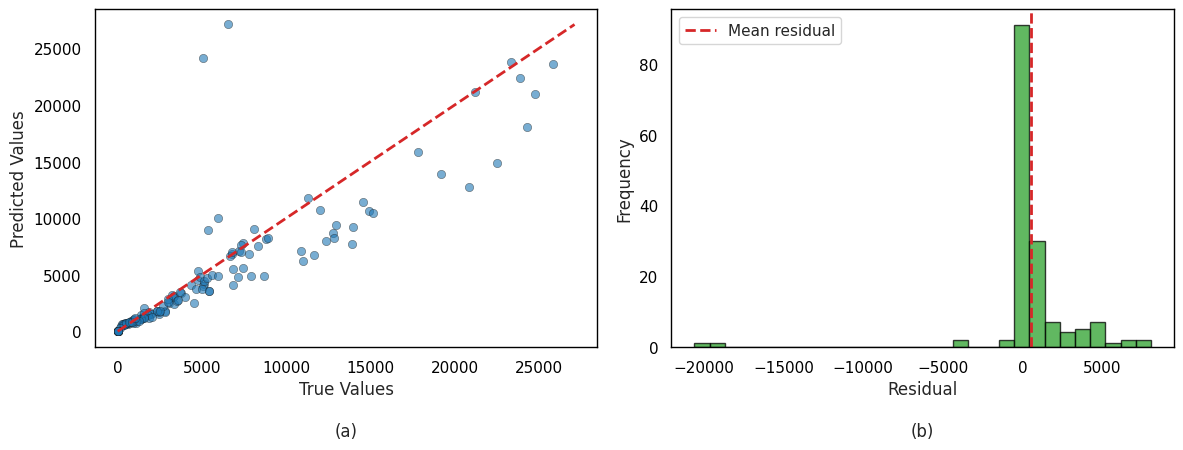

In [58]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Get predictions on test set
# -----------------------------
y_reg_pred_scaled = multi_model.predict(X_test_scaled)[0]  # regression output

# Reverse scaling and log-transform
y_reg_pred = np.expm1(scaler_y.inverse_transform(y_reg_pred_scaled))
y_reg_true = y_reg_test.flatten()  # original regression target

# Residuals
residuals = y_reg_true - y_reg_pred.flatten()

# -----------------------------
# Side-by-side plots
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) Actual vs Predicted
axes[0].scatter(
    y_reg_true,
    y_reg_pred,
    color="tab:blue",
    alpha=0.6,
    edgecolors="k",
    linewidths=0.4
)

mn = float(min(y_reg_true.min(), y_reg_pred.min()))
mx = float(max(y_reg_true.max(), y_reg_pred.max()))

axes[0].plot(
    [mn, mx], [mn, mx],
    color="tab:red",
    linestyle="--",
    linewidth=2
)

axes[0].set_xlabel("True Values")
axes[0].set_ylabel("Predicted Values")
axes[0].grid(False)

# Panel label (a)
axes[0].text(
    0.5, -0.25, "(a)",
    ha="center", va="center",
    transform=axes[0].transAxes
)

# (b) Residuals distribution
axes[1].hist(
    residuals,
    bins=30,
    color="tab:green",
    alpha=0.75,
    edgecolor="black"
)

axes[1].axvline(
    residuals.mean(),
    color="tab:red",
    linestyle="--",
    linewidth=2,
    label="Mean residual"
)

axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].legend()
axes[1].grid(False)

# Panel label (b)
axes[1].text(
    0.5, -0.25, "(b)",
    ha="center", va="center",
    transform=axes[1].transAxes
)

# Match clean border style
for ax in axes:
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.0)
    ax.tick_params(axis='both', direction='out', colors='black', length=6, width=1.0)

plt.subplots_adjust(bottom=0.28)
plt.tight_layout()
plt.show()


In [67]:
import numpy as np
from sklearn.preprocessing import StandardScaler, RobustScaler
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, Dropout, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Clear previous TF session
K.clear_session()
print("✅ Cleared previous TensorFlow session.")


✅ Cleared previous TensorFlow session.


In [68]:
# Convert to 2D if needed
X_train_2d = X_train_lstm.reshape(X_train_lstm.shape[0], -1)
X_val_2d   = X_val_lstm.reshape(X_val_lstm.shape[0], -1)
X_test_2d  = X_test_lstm.reshape(X_test_lstm.shape[0], -1)

# Replace NaNs/Infs with column median
for arr in [X_train_2d, X_val_2d, X_test_2d]:
    col_median = np.nanmedian(arr, axis=0)
    inds_nan = np.isnan(arr)
    inds_inf = np.isinf(arr)
    arr[inds_nan] = np.take(col_median, np.where(inds_nan)[1])
    arr[inds_inf] = np.take(col_median, np.where(inds_inf)[1])

# Standardize features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_2d)
X_val_scaled   = scaler_X.transform(X_val_2d)
X_test_scaled  = scaler_X.transform(X_test_2d)

n_features = X_train_scaled.shape[1]
print(f"✅ Features standardized. Number of features: {n_features}")


✅ Features standardized. Number of features: 6


In [69]:
y_reg_train = np.array(y_reg_train).reshape(-1,1)
y_reg_val   = np.array(y_reg_val).reshape(-1,1)
y_reg_test  = np.array(y_reg_test).reshape(-1,1)

# Replace NaNs/Infs with median
for arr in [y_reg_train, y_reg_val, y_reg_test]:
    median_val = np.nanmedian(arr)
    arr[np.isnan(arr)] = median_val
    arr[np.isinf(arr)] = median_val

# Optional log-transform for wide range
y_reg_train_log = np.log1p(y_reg_train)
y_reg_val_log   = np.log1p(y_reg_val)
y_reg_test_log  = np.log1p(y_reg_test)

# Use RobustScaler to reduce impact of outliers
scaler_y = RobustScaler()
y_reg_train_scaled = scaler_y.fit_transform(y_reg_train_log)
y_reg_val_scaled   = scaler_y.transform(y_reg_val_log)
y_reg_test_scaled  = scaler_y.transform(y_reg_test_log)

print("✅ Regression target cleaned, log-transformed, and scaled.")


✅ Regression target cleaned, log-transformed, and scaled.


In [61]:
y_class_train = np.array(y_class_train).reshape(-1,1)
y_class_val   = np.array(y_class_val).reshape(-1,1)
y_class_test  = np.array(y_class_test).reshape(-1,1)

# Ensure 0/1 and finite
for arr in [y_class_train, y_class_val, y_class_test]:
    arr[np.isnan(arr)] = 0
    arr[arr>1] = 1

print("✅ Classification target cleaned.")


✅ Classification target cleaned.


In [70]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1)
]


In [71]:
inputs = Input(shape=(n_features,))

# Shared dense layers
x = Dense(32)(inputs)
x = LeakyReLU(negative_slope=0.1)(x)
x = Dropout(0.2)(x)
x = Dense(16)(x)
x = LeakyReLU(negative_slope=0.1)(x)

# Regression branch
regression_output = Dense(1, activation='linear', name='regression')(x)

# Classification branch
classification_output = Dense(1, activation='sigmoid', name='classification')(x)

# Multi-output model
multi_model = Model(inputs=inputs, outputs=[regression_output, classification_output])

# Compile model with weighted losses to balance regression and classification
multi_model.compile(
    optimizer=Adam(1e-4),
    loss={'regression': 'mse', 'classification': 'binary_crossentropy'},
    loss_weights={'regression': 1.0, 'classification': 1.0},
    metrics={'regression': ['mae', 'mse'], 'classification': ['accuracy','Precision','Recall','AUC']}
)

multi_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        224 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 32)        │          0 │ dense[0][0]       │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        528 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 16)        │          0 │ dense_1[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ regression (Dense)  │ (None, 1)         │         17 │ leaky_re_lu_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification      │ (None, 1)         │         17 │ leaky_re_lu_1[0]… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 786 (3.07 KB)

 Trainable params: 786 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
history = multi_model.fit(
    X_train_scaled,
    {'regression': y_reg_train_scaled, 'classification': y_class_train},
    validation_data=(X_val_scaled, {'regression': y_reg_val_scaled, 'classification': y_class_val}),
    epochs=150,
    batch_size=8,
    callbacks=callbacks,
    verbose=1
)
print("✅ Multi-output model trained successfully.")


Epoch 1/150
71/71 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - classification_AUC: 0.6914 - classification_Precision: 0.3361 - classification_Recall: 0.9528 - classification_accuracy: 0.4704 - classification_loss: 0.7171 - loss: 2.5141 - regression_loss: 1.7966 - regression_mae: 1.0512 - regression_mse: 1.7970 - val_classification_AUC: 0.7391 - val_classification_Precision: 0.3404 - val_classification_Recall: 0.9412 - val_classification_accuracy: 0.4921 - val_classification_loss: 0.6972 - val_loss: 2.0281 - val_regression_loss: 1.3381 - val_regression_mae: 0.8491 - val_regression_mse: 1.3317 - learning_rate: 1.0000e-04
Epoch 2/150
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - classification_AUC: 0.6886 - classification_Precision: 0.3115 - classification_Recall: 0.9001 - classification_accuracy: 0.4576 - classification_loss: 0.7326 - loss: 2.1505 - regression_loss: 1.4177 - regression_mae: 0.9013 - regression_mse: 1.4180 - val_classification_AUC: 0.7385 - val_classification_Precision: 0.3333 - val_cl

In [73]:
multi_model.save("multi_output_model.keras")  # Recommended Keras format
print("✅ Multi-output model saved successfully!")


✅ Multi-output model saved successfully!


In [74]:
from tensorflow.keras.models import load_model

loaded_model = load_model("multi_output_model.keras")
print("✅ Multi-output model loaded successfully!")


✅ Multi-output model loaded successfully!


In [75]:
# Regression predictions
y_reg_pred_scaled, y_class_pred = loaded_model.predict(X_test_scaled)

# Reverse scaling & log-transform
y_reg_pred = np.expm1(scaler_y.inverse_transform(y_reg_pred_scaled))
y_class_pred_binary = (y_class_pred > 0.5).astype(int)

print("Regression predictions (first 10):", y_reg_pred[:10].flatten())
print("Classification predictions (first 10):", y_class_pred_binary[:10].flatten())


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Regression predictions (first 10): [2427.805   5448.0947   608.653    630.6673   735.34406 1297.3363
 2573.401   6413.586    490.17487 5776.305  ]
Classification predictions (first 10): [0 0 0 0 0 0 0 0 0 0]


1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


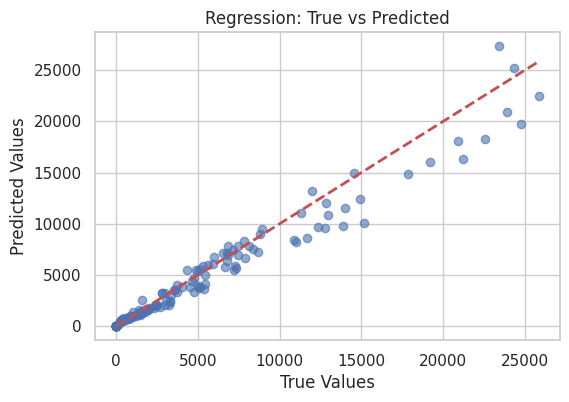

In [76]:
import matplotlib.pyplot as plt

# Get predictions on test set
y_reg_pred_scaled = multi_model.predict(X_test_scaled)[0]  # regression output
# Reverse scaling and log-transform
y_reg_pred = np.expm1(scaler_y.inverse_transform(y_reg_pred_scaled))
y_reg_true = y_reg_test.flatten()  # original regression target

# Scatter plot
plt.figure(figsize=(6,4))
plt.scatter(y_reg_true, y_reg_pred, alpha=0.6)
plt.plot([y_reg_true.min(), y_reg_true.max()],
         [y_reg_true.min(), y_reg_true.max()],
         'r--', linewidth=2)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Regression: True vs Predicted")
# plt.grid(True)
plt.show()


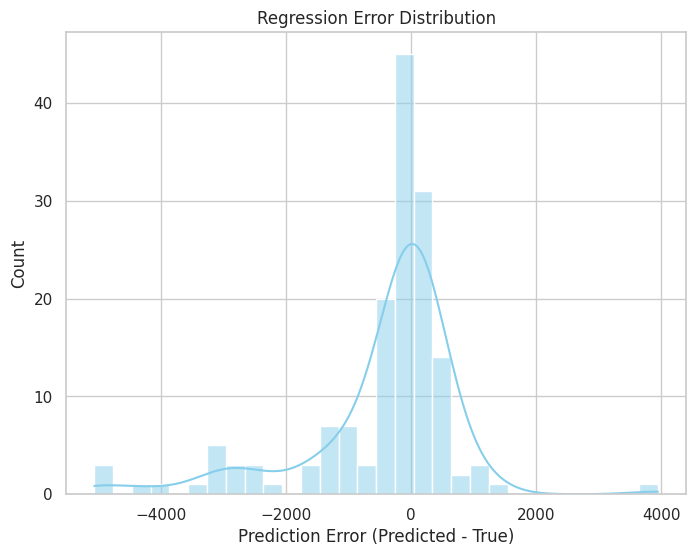

In [77]:
import seaborn as sns

# Calculate errors
reg_errors = y_reg_pred.flatten() - y_reg_true

# Plot error distribution
plt.figure(figsize=(8,6))
sns.histplot(reg_errors, bins=30, kde=True, color='skyblue')
plt.xlabel("Prediction Error (Predicted - True)")
plt.ylabel("Count")
plt.title("Regression Error Distribution")
plt.grid(True)
plt.show()


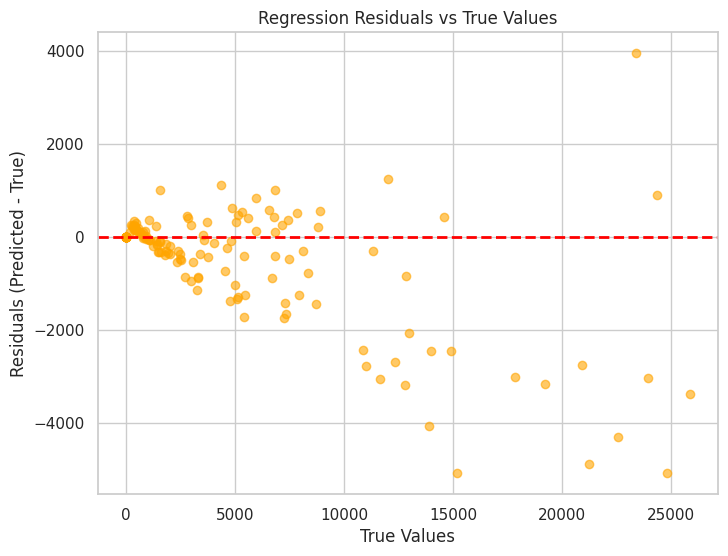

In [78]:
# Regression Residuals
reg_residuals = y_reg_pred.flatten() - y_reg_true

plt.figure(figsize=(8,6))
plt.scatter(y_reg_true, reg_residuals, alpha=0.6, color='orange')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel("True Values")
plt.ylabel("Residuals (Predicted - True)")
plt.title("Regression Residuals vs True Values")
plt.grid(True)
plt.show()


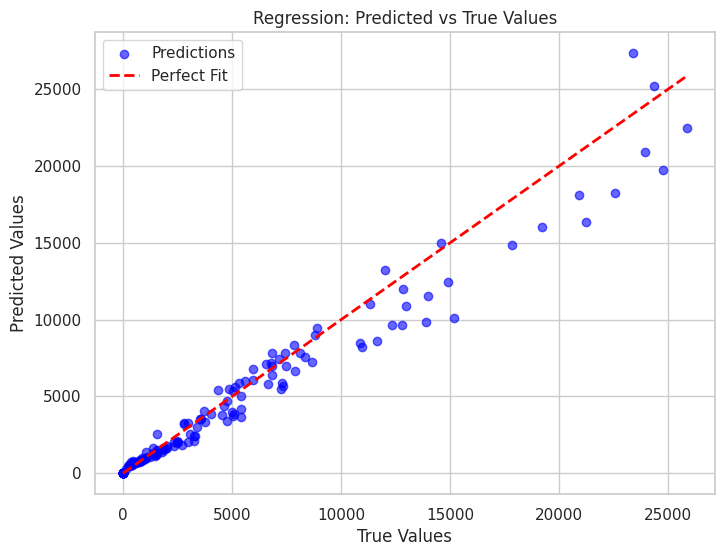

In [79]:
plt.figure(figsize=(8,6))
plt.scatter(y_reg_true, y_reg_pred.flatten(), alpha=0.6, color='blue', label="Predictions")
plt.plot([y_reg_true.min(), y_reg_true.max()],
         [y_reg_true.min(), y_reg_true.max()],
         color='red', linestyle='--', linewidth=2, label="Perfect Fit")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Regression: Predicted vs True Values")
plt.legend()
plt.grid(True)
plt.show()


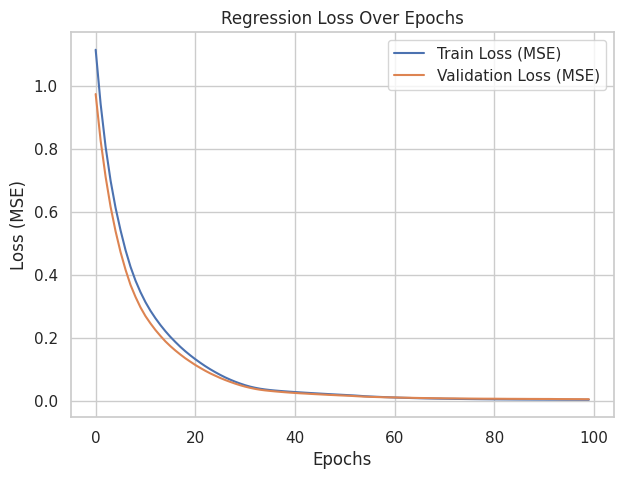

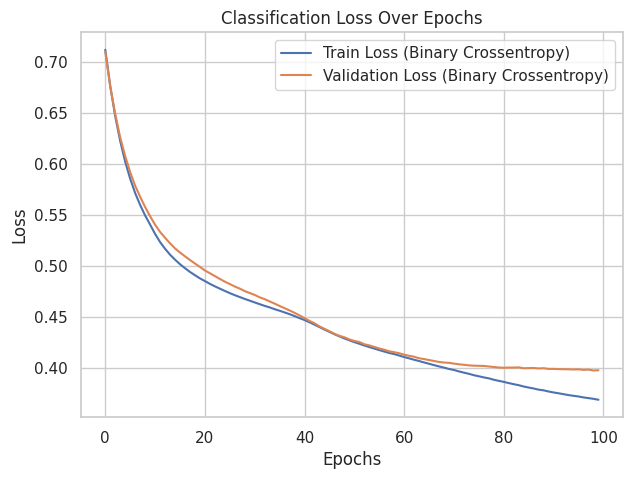

In [80]:
import matplotlib.pyplot as plt

# -----------------------------
# Regression Loss
# -----------------------------
plt.figure(figsize=(7,5))
plt.plot(reg_history.history['loss'], label='Train Loss (MSE)')
plt.plot(reg_history.history['val_loss'], label='Validation Loss (MSE)')
plt.title("Regression Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
#plt.grid(True)
plt.show()

# -----------------------------
# Classification Loss
# -----------------------------
plt.figure(figsize=(7,5))
plt.plot(class_history.history['loss'], label='Train Loss (Binary Crossentropy)')
plt.plot(class_history.history['val_loss'], label='Validation Loss (Binary Crossentropy)')
plt.title("Classification Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [81]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_class_pred = (class_model.predict(X_test_scaled) > 0.5).astype(int)
acc = accuracy_score(y_class_test, y_class_pred)
precision = precision_score(y_class_test, y_class_pred)
recall = recall_score(y_class_test, y_class_pred)
f1 = f1_score(y_class_test, y_class_pred)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


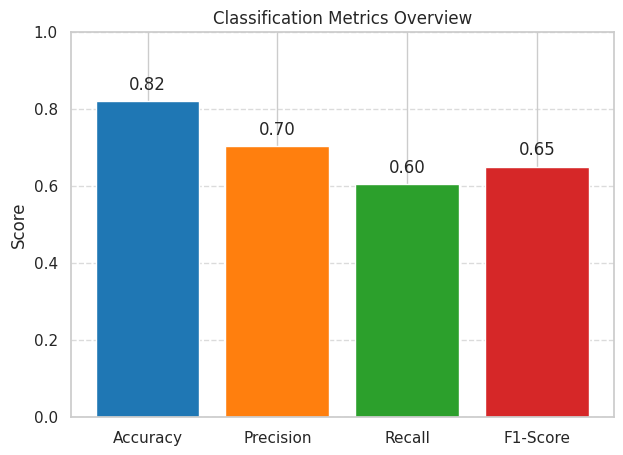

In [82]:
import matplotlib.pyplot as plt

# Ensure your metrics are scalar floats
acc = float(acc)
precision = float(precision)
recall = float(recall)
f1 = float(f1)

# Metrics
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [acc, precision, recall, f1]

plt.figure(figsize=(7,5))
bars = plt.bar(metrics_names, metrics_values, color=['#1f77b4','#ff7f0e','#2ca02c','#d62728'])
plt.ylim(0,1)
plt.title("Classification Metrics Overview")
plt.ylabel("Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate values on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', va='bottom')

plt.show()


In [83]:
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.optimizers import Adam

# Example shapes: adjust according to your dataset
timesteps = X_train_lstm.shape[1]   # e.g., 10
n_features = X_train_lstm.shape[2]  # e.g., 6

# -----------------------------
# Input Layer
# -----------------------------
inputs = Input(shape=(timesteps, n_features))

# -----------------------------
# LSTM Layer
# -----------------------------
x = LSTM(32, return_sequences=False)(inputs)
x = Dense(32, activation='relu')(x)

# -----------------------------
# Regression outputs (Growth Rate, Direction, Size)
# -----------------------------
growth_rate = Dense(1, activation='linear', name='growth_rate')(x)
growth_dir  = Dense(1, activation='linear', name='growth_dir')(x)
size        = Dense(1, activation='linear', name='size')(x)

# -----------------------------
# Classification outputs (Shape irregularity, Margin irregularity)
# -----------------------------
shape_irreg   = Dense(1, activation='sigmoid', name='shape_irreg')(x)
margin_irreg  = Dense(1, activation='sigmoid', name='margin_irreg')(x)

# -----------------------------
# Build model
# -----------------------------
lstm_model = Model(inputs=inputs, outputs=[growth_rate, growth_dir, size, shape_irreg, margin_irreg])
lstm_model.compile(
    optimizer=Adam(1e-4),
    loss={'growth_rate':'mse', 'growth_dir':'mse', 'size':'mse',
          'shape_irreg':'binary_crossentropy', 'margin_irreg':'binary_crossentropy'},
    metrics={'growth_rate':'mae', 'growth_dir':'mae', 'size':'mae',
             'shape_irreg':'accuracy', 'margin_irreg':'accuracy'}
)

lstm_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1, 6)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 32)        │      4,992 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      1,056 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ growth_rate (Dense) │ (None, 1)         │         33 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ growth_dir (Dense)  │ (None, 1)         │         33 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ size (Dense)        │ (None, 1)         │         33 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shape_irreg (Dense) │ (None, 1)         │         33 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ margin_irreg        │ (None, 1)         │         33 │ dense_2[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,213 (24.27 KB)

 Trainable params: 6,213 (24.27 KB)

 Non-trainable params: 0 (0.00 B)

In [84]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# -----------------------------
# Callbacks
# -----------------------------
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

# -----------------------------
# Train the model
# -----------------------------
history = lstm_model.fit(
    X_train_lstm,
    {
        'growth_rate': y_growth_rate_train,
        'growth_dir': y_growth_dir_train,
        'size': y_size_train,
        'shape_irreg': y_shape_irreg_train,
        'margin_irreg': y_margin_irreg_train
    },
    validation_data=(
        X_val_lstm,
        {
            'growth_rate': y_growth_rate_val,
            'growth_dir': y_growth_dir_val,
            'size': y_size_val,
            'shape_irreg': y_shape_irreg_val,
            'margin_irreg': y_margin_irreg_val
        }
    ),
    epochs=150,
    batch_size=8,
    callbacks=callbacks,
    verbose=1
)
print("✅ LSTM multi-output model trained successfully!")


NameError: name 'y_growth_rate_train' is not defined